<a href="https://colab.research.google.com/github/ksyushik31/python-ai-Puhlenko-Ksenia/blob/main/notebooks/week3_visualization_crack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ==============================================
# 📥 ШАГ 1: ИМПОРТ БИБЛИОТЕК И ЗАГРУЗКА ДАННЫХ
# ==============================================

# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Настройка для отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("✅ Библиотеки импортированы")
print("="*70)

# ==============================================
# 📁 ЗАГРУЗКА ВСЕХ ДАТАСЕТОВ ИЗ GITHUB
# ==============================================

# Ссылки на файлы (raw-формат)
urls = {
    'info': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_info.csv',
    'visitors': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/park_visitors.csv',
    'social': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_social.csv',
    'types': 'https://raw.githubusercontent.com/ksyushik31/python-ai-Puhlenko-Ksenia/main/data/parks_types.csv'
}

# Загружаем данные
df_info = pd.read_csv(urls['info'])
df_visitors = pd.read_csv(urls['visitors'])
df_social = pd.read_csv(urls['social'])
df_types = pd.read_csv(urls['types'])

print("📊 Данные успешно загружены!")
print(f"• df_info: {df_info.shape} (строк, столбцов)")
print(f"• df_visitors: {df_visitors.shape}")
print(f"• df_social: {df_social.shape}")
print(f"• df_types: {df_types.shape}")
print("="*70)

# ==============================================
# 🔍 ЧАСТЬ 1: ДИАГНОСТИКА СТРУКТУРЫ ДАННЫХ
# ==============================================

# Словарь с датафреймами для удобной обработки
dfs = {
    'df_info': df_info,
    'df_visitors': df_visitors,
    'df_social': df_social,
    'df_types': df_types
}

# Функция для диагностики одного датафрейма
def diagnose_df(name, df):
    print(f"\n{'='*60}")
    print(f"=== {name} ===")
    print(f"{'='*60}")

    # 1. Список столбцов
    print(f"\n📋 Столбцы:")
    print(df.columns.tolist())

    # 2. Размер таблицы
    print(f"\n📏 Размер: {df.shape}")

    # 3. Первые 2 строки
    print(f"\n👀 Первые 2 строки:")
    display(df.head(2))

    # 4. Типы данных
    print(f"\n🔢 Типы данных:")
    print(df.dtypes)

    # 5. Проверка на пропуски
    print(f"\n⚠️ Пропуски (NaN):")
    missing = df.isna().sum()
    missing_pct = (missing / len(df) * 100).round(1)
    missing_df = pd.DataFrame({
        'Пропусков': missing,
        'Процент': missing_pct
    })
    display(missing_df[missing_df['Пропусков'] > 0])

# Запускаем диагностику для каждого датафрейма
for name, df in dfs.items():
    diagnose_df(name, df)
    print(f"\n{'─'*60}")

print("\n✅ Диагностика завершена!")

✅ Библиотеки импортированы
📊 Данные успешно загружены!
• df_info: (4878, 8) (строк, столбцов)
• df_visitors: (645, 4)
• df_social: (183, 4)
• df_types: (1426, 4)

=== df_info ===

📋 Столбцы:
['park', 'parkLabel', 'countryLabel', 'continentLabel', 'areaKm2', 'inceptionYear', 'elevation', 'coord']

📏 Размер: (4878, 8)

👀 Первые 2 строки:


,park,parkLabel,countryLabel,continentLabel,areaKm2,inceptionYear,elevation,coord
0,http://www.wikidata.org/entity/Q211816,Pioneer Peaks National Park,Австралия,Австралия и Океания,18.801129,2004.0,142.0,Point(148.923888888 -20.983888888)
1,http://www.wikidata.org/entity/Q211816,Pioneer Peaks National Park,Австралия,Австралия и Океания,189.000000,2004.0,142.0,Point(148.923888888 -20.983888888)



🔢 Типы данных:
park               object
parkLabel          object
countryLabel       object
continentLabel     object
areaKm2           float64
inceptionYear     float64
elevation         float64
coord              object
dtype: object

⚠️ Пропуски (NaN):


,Пропусков,Процент
inceptionYear,141,2.9
elevation,2414,49.5
coord,25,0.5



────────────────────────────────────────────────────────────

=== df_visitors ===

📋 Столбцы:
['park', 'parkLabel', 'visitors', 'year']

📏 Размер: (645, 4)

👀 Первые 2 строки:


...


────────────────────────────────────────────────────────────

=== df_types ===

📋 Столбцы:
['park', 'parkLabel', 'instanceType', 'instanceTypeLabel']

📏 Размер: (1426, 4)

👀 Первые 2 строки:


,park,parkLabel,instanceType,instanceTypeLabel
0,http://www.wikidata.org/entity/Q488639,Taeanhaean National Park,http://www.wikidata.org/entity/Q179049,заповедник
1,http://www.wikidata.org/entity/Q488639,Taeanhaean National Park,http://www.wikidata.org/entity/Q473972,природоохранная зона



🔢 Типы данных:
park                 object
parkLabel            object
instanceType         object
instanceTypeLabel    object
dtype: object

⚠️ Пропуски (NaN):


,Пропусков,Процент



────────────────────────────────────────────────────────────

✅ Диагностика завершена!


In [3]:
# ==============================================
# 🛠️ ЧАСТЬ 2: ПОДГОТОВКА ДАННЫХ (6 шагов)
# ==============================================

print("="*70)
print("🔧 ШАГ 2.1: ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ")
print("="*70)

# Создаем копии для безопасной работы
df_info_clean = df_info.copy()
df_visitors_clean = df_visitors.copy()
df_social_clean = df_social.copy()
df_types_clean = df_types.copy()

# --- df_info: переименование ---
print("\n📁 df_info:")
# 'park' → 'URL' (ключевой столбец)
if 'park' in df_info_clean.columns:
    df_info_clean = df_info_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")

# *Label → короткие имена
label_columns = {
    'parkLabel': 'park',
    'countryLabel': 'country',
    'continentLabel': 'continent'
}
for old, new in label_columns.items():
    if old in df_info_clean.columns:
        df_info_clean = df_info_clean.rename(columns={old: new})
        print(f"✅ '{old}' → '{new}'")

# --- df_visitors: переименование ---
print("\n📁 df_visitors:")
if 'park' in df_visitors_clean.columns:
    df_visitors_clean = df_visitors_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_visitors_clean.columns:
    df_visitors_clean = df_visitors_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")

# --- df_social: переименование ---
print("\n📁 df_social:")
if 'park' in df_social_clean.columns:
    df_social_clean = df_social_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_social_clean.columns:
    df_social_clean = df_social_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")

# --- df_types: переименование ---
print("\n📁 df_types:")
if 'park' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'park': 'URL'})
    print("✅ 'park' → 'URL'")
if 'parkLabel' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'parkLabel': 'park'})
    print("✅ 'parkLabel' → 'park'")
if 'instanceTypeLabel' in df_types_clean.columns:
    df_types_clean = df_types_clean.rename(columns={'instanceTypeLabel': 'type'})
    print("✅ 'instanceTypeLabel' → 'type'")

print("\n" + "="*70)
print("🔢 ШАГ 2.2: ПРИВЕДЕНИЕ ТИПОВ ДАННЫХ")
print("="*70)
print("⚠️ ВАЖНО: НЕ применяем fillna(0) к optional-полям!")

# Числовые столбцы для преобразования
numeric_columns_info = ['areaKm2', 'elevation', 'inceptionYear']
numeric_columns_visitors = ['visitors', 'year']
numeric_columns_social = ['followers', 'year']

# df_info
print("\n📁 df_info:")
for col in numeric_columns_info:
    if col in df_info_clean.columns:
        df_info_clean[col] = pd.to_numeric(df_info_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

# df_visitors
print("\n📁 df_visitors:")
for col in numeric_columns_visitors:
    if col in df_visitors_clean.columns:
        df_visitors_clean[col] = pd.to_numeric(df_visitors_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

# df_social
print("\n📁 df_social:")
for col in numeric_columns_social:
    if col in df_social_clean.columns:
        df_social_clean[col] = pd.to_numeric(df_social_clean[col], errors='coerce')
        print(f"✅ '{col}' → числовой тип (float)")

print("\n" + "="*70)
print("🔄 ШАГ 2.3: УДАЛЕНИЕ ДУБЛИКАТОВ (df_info)")
print("="*70)

rows_before = len(df_info_clean)
print(f"📊 Строк до удаления: {rows_before}")

# Сортируем по inceptionYear (от старых к новым) и удаляем дубликаты URL
if 'inceptionYear' in df_info_clean.columns:
    df_info_clean = df_info_clean.sort_values('inceptionYear', ascending=True)
    df_info_clean = df_info_clean.drop_duplicates(subset='URL', keep='first')
else:
    df_info_clean = df_info_clean.drop_duplicates(subset='URL', keep='first')

rows_after = len(df_info_clean)
rows_removed = rows_before - rows_after

print(f"📊 Строк после удаления: {rows_after}")
print(f"🗑️ Удалено дубликатов: {rows_removed}")
print(f"✅ Уникальных URL теперь: {df_info_clean['URL'].nunique()}")

print("\n" + "="*70)
print("📍 ШАГ 2.4: ПАРСИНГ КООРДИНАТ")
print("="*70)

import re

def parse_coord(coord_str):
    """
    Парсит строку 'Point(lon lat)' в долготу и широту
    Пример: 'Point(148.92 -20.98)' → (148.92, -20.98)
    """
    if pd.isna(coord_str) or not isinstance(coord_str, str):
        return pd.Series([None, None])

    # Регулярное выражение для извлечения двух чисел
    match = re.search(r'Point\(([-\d.]+)\s+([-\d.]+)\)', coord_str)

    if match:
        lon = float(match.group(1))
        lat = float(match.group(2))
        return pd.Series([lon, lat])

    return pd.Series([None, None])

# Применяем парсинг
if 'coord' in df_info_clean.columns:
    print("⏳ Извлечение координат...")
    df_info_clean[['longitude', 'latitude']] = df_info_clean['coord'].apply(parse_coord)

    # Статистика
    coord_count = df_info_clean['latitude'].notna().sum()
    total = len(df_info_clean)
    print(f"✅ Координаты извлечены для {coord_count} из {total} парков ({coord_count/total*100:.1f}%)")

    # Проверка аномалий
    lat_invalid = ((df_info_clean['latitude'] < -90) | (df_info_clean['latitude'] > 90)).sum()
    lon_invalid = ((df_info_clean['longitude'] < -180) | (df_info_clean['longitude'] > 180)).sum()
    print(f"✅ Аномалий не найдено: широта={lat_invalid}, долгота={lon_invalid}")

print("\n" + "="*70)
print("🔗 ШАГ 2.5: ОБЪЕДИНЕНИЕ ТАБЛИЦ")
print("="*70)

# 1. Находим год с максимальным покрытием для visitors
print("\n📈 Анализ покрытия по годам (visitors):")
year_coverage = df_visitors_clean.groupby('year')['URL'].nunique().sort_values(ascending=False)
best_year_visitors = year_coverage.index[0]
best_year_count = year_coverage.iloc[0]
print(f"🏆 Лучший год: {int(best_year_visitors)} (данные для {best_year_count} парков)")

# 2. Находим год с максимальным покрытием для social
print("\n📱 Анализ покрытия по годам (social):")
year_coverage_social = df_social_clean.groupby('year')['URL'].nunique().sort_values(ascending=False)
best_year_social = year_coverage_social.index[0]
best_year_social_count = year_coverage_social.iloc[0]
print(f"🏆 Лучший год: {int(best_year_social)} (данные для {best_year_social_count} парков)")

# 3. Создаем срезы за лучшие годы
visitors_best = df_visitors_clean[df_visitors_clean['year'] == best_year_visitors][['URL', 'visitors']].copy()
social_best = df_social_clean[df_social_clean['year'] == best_year_social][['URL', 'followers']].copy()

# 4. Объединяем всё в один датафрейм
df_merged = df_info_clean.copy()

# Добавляем посетителей
df_merged = pd.merge(df_merged, visitors_best, on='URL', how='left')
print(f"\n✅ После добавления visitors: {df_merged['visitors'].notna().sum()} парков с данными")

# Добавляем подписчиков
df_merged = pd.merge(df_merged, social_best, on='URL', how='left')
print(f"✅ После добавления followers: {df_merged['followers'].notna().sum()} парков с данными")

# 5. Считаем итоговое пересечение
complete_cases = df_merged[['visitors', 'followers']].notna().all(axis=1).sum()
print(f"\n🎯 Итоговое пересечение (есть и visitors, и followers): {complete_cases} парков")

print("\n" + "="*70)
print("📊 ШАГ 2.6: ДОБАВЛЕНИЕ ЛОГАРИФМИЧЕСКИХ СТОЛБЦОВ")
print("="*70)

# Добавляем log_visitors (псевдо-счет, чтобы избежать -inf)
df_merged['log_visitors'] = np.log1p(df_merged['visitors'].fillna(0))
df_merged['log_followers'] = np.log1p(df_merged['followers'].fillna(0))

# Проверка результатов
print("✅ Логарифмические столбцы созданы:")
print(f"   • log_visitors: от {df_merged['log_visitors'].min():.2f} до {df_merged['log_visitors'].max():.2f}")
print(f"   • log_followers: от {df_merged['log_followers'].min():.2f} до {df_merged['log_followers'].max():.2f}")

print("\n" + "="*70)
print("📋 ФИНАЛЬНАЯ ПРОВЕРКА ДАННЫХ")
print("="*70)

print(f"\n📊 df_info_clean: {df_info_clean.shape}")
print(f"📊 df_merged (основной для визуализаций): {df_merged.shape}")

print("\n🔍 Первые 3 строки финального датафрейма:")
display(df_merged[['park', 'country', 'areaKm2', 'visitors', 'followers', 'longitude', 'latitude']].head(3))

print("\n📊 Статистика пропусков в финальном датафрейме:")
missing_final = df_merged[['visitors', 'followers', 'elevation', 'inceptionYear']].isna().sum()
display(pd.DataFrame({'Пропусков': missing_final}))

print("\n" + "="*70)
print("✅ ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА!")
print("="*70)
print("\n💡 Дальнейшие шаги (по вашему запросу):")
print("   • Часть 3: Анализ выбросов и распределений")
print("   • Часть 4: Временные ряды")
print("   • Часть 5: Корреляционный анализ")
print("   • Часть 6: Интерактивные визуализации")

🔧 ШАГ 2.1: ПЕРЕИМЕНОВАНИЕ СТОЛБЦОВ

📁 df_info:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'
✅ 'countryLabel' → 'country'
✅ 'continentLabel' → 'continent'

📁 df_visitors:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'

📁 df_social:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'

📁 df_types:
✅ 'park' → 'URL'
✅ 'parkLabel' → 'park'
✅ 'instanceTypeLabel' → 'type'

🔢 ШАГ 2.2: ПРИВЕДЕНИЕ ТИПОВ ДАННЫХ
⚠️ ВАЖНО: НЕ применяем fillna(0) к optional-полям!

📁 df_info:
✅ 'areaKm2' → числовой тип (float)
✅ 'elevation' → числовой тип (float)
✅ 'inceptionYear' → числовой тип (float)

📁 df_visitors:
✅ 'visitors' → числовой тип (float)
✅ 'year' → числовой тип (float)

📁 df_social:
✅ 'followers' → числовой тип (float)
✅ 'year' → числовой тип (float)

🔄 ШАГ 2.3: УДАЛЕНИЕ ДУБЛИКАТОВ (df_info)
📊 Строк до удаления: 4878
📊 Строк после удаления: 1954
🗑️ Удалено дубликатов: 2924
✅ Уникальных URL теперь: 1954

📍 ШАГ 2.4: ПАРСИНГ КООРДИНАТ
⏳ Извлечение координат...
✅ Координаты извлечены для 1930 из 1954 парков (98.8%)
✅ Аномалий н

,park,country,areaKm2,visitors,followers,longitude,latitude
0,Нитмилук,Австралия,1131.729766,NaN,NaN,132.423000,-14.312200
1,Previously called Mafou Classified Forest Nati...,Гвинея,524.000000,NaN,NaN,NaN,NaN
2,Форт Иисус,Кения,0.310000,NaN,NaN,39.682056,-4.071167



📊 Статистика пропусков в финальном датафрейме:


,Пропусков
visitors,1901
followers,1902
elevation,1323
inceptionYear,126



✅ ПОДГОТОВКА ДАННЫХ ЗАВЕРШЕНА!

💡 Дальнейшие шаги (по вашему запросу):
   • Часть 3: Анализ выбросов и распределений
   • Часть 4: Временные ряды
   • Часть 5: Корреляционный анализ
   • Часть 6: Интерактивные визуализации


In [4]:
# ==============================================
# 🔍 ДИАГНОСТИКА: КАКИЕ ДАННЫЕ ГДЕ ЛЕЖАТ
# ==============================================

print("="*70)
print("📊 ДИАГНОСТИКА ДАТАСЕТОВ")
print("="*70)

# 1. Общий размер
print(f"\n📏 Общий размер df_merged: {df_merged.shape}")

# 2. Проверяем наличие данных по visitors и followers
print("\n🔍 Наличие данных:")

visitors_count = df_merged['visitors'].notna().sum()
followers_count = df_merged['followers'].notna().sum()
both_count = df_merged[['visitors', 'followers']].notna().all(axis=1).sum()

print(f"   • Парков с visitors: {visitors_count}")
print(f"   • Парков с followers: {followers_count}")
print(f"   • Парков с И ТЕМ, И ДРУГИМ: {both_count} ⭐ (это наши 44!)")

# 3. Создаём правильные датасеты для разных целей
print("\n" + "="*70)
print("🎯 СОЗДАНИЕ ЦЕЛЕВЫХ ДАТАСЕТОВ")
print("="*70)

# ДЛЯ РЕГРЕССИИ/КОРРЕЛЯЦИИ: только полные данные (44 парка)
df_regression = df_merged[df_merged[['visitors', 'followers']].notna().all(axis=1)].copy()
print(f"\n✅ df_regression: {df_regression.shape}")
print(f"   • Использовать для: регрессия, корреляция, scatter plots")
print(f"   • Содержит только парки с visitors И followers")

# ДЛЯ КАРТЫ: все парки с координатами (1930 парков)
df_map = df_merged[df_merged['latitude'].notna()].copy()
print(f"\n✅ df_map: {df_map.shape}")
print(f"   • Использовать для: интерактивные карты")
print(f"   • Содержит все парки с координатами")

# ДЛЯ ВРЕМЕННЫХ РЯДОВ: исходные длинные форматы
print(f"\n✅ df_visitors_clean: {df_visitors_clean.shape}")
print(f"   • Использовать для: временные ряды посетителей")
print(f"✅ df_social_clean: {df_social_clean.shape}")
print(f"   • Использовать для: временные ряды подписчиков")

# ДЛЯ ТИПОВ ПАРКОВ: длинный формат с типами
print(f"\n✅ df_types_clean: {df_types_clean.shape}")
print(f"   • Использовать для: анализ категорий")

# ДЛЯ ТОП-ЛИСТОВ: все парки из info (1955 строк)
df_all_parks = df_merged.copy()
print(f"\n✅ df_all_parks: {df_all_parks.shape}")
print(f"   • Использовать для: гистограммы, топ-чарты по площади/годам")

print("\n" + "="*70)
print("💡 ОТВЕТЫ НА ВАШИ ВОПРОСЫ:")
print("="*70)
print("""
1. Где финальный датасет для визуализации (44 парка)?
   → df_regression (создан выше)

2. df_merged, df_final или другая переменная?
   → df_merged - это ПОЛНЫЙ датасет (1955 строк)
   → df_regression - это ПОДМНОЖЕСТВО для регрессии (44 строки)

3. Какой датасет использовать для регрессии?
   → ТОЛЬКО df_regression!
   → Регрессия на неполных данных даст некорректные результаты
""")

# Проверяем корреляцию на правильных данных
print("\n" + "="*70)
print("📈 ПРОВЕРКА КОРРЕЛЯЦИИ НА df_regression:")
print("="*70)

if len(df_regression) > 0:
    corr = df_regression['visitors'].corr(df_regression['followers'])
    print(f"✅ Корреляция visitors vs followers: {corr:.3f}")
    print(f"📊 На выборке из {len(df_regression)} парков")
else:
    print("⚠️ Нет данных для расчёта корреляции")

📊 ДИАГНОСТИКА ДАТАСЕТОВ

📏 Общий размер df_merged: (1955, 14)

🔍 Наличие данных:
   • Парков с visitors: 54
   • Парков с followers: 53
   • Парков с И ТЕМ, И ДРУГИМ: 44 ⭐ (это наши 44!)

🎯 СОЗДАНИЕ ЦЕЛЕВЫХ ДАТАСЕТОВ

✅ df_regression: (44, 14)
   • Использовать для: регрессия, корреляция, scatter plots
   • Содержит только парки с visitors И followers

✅ df_map: (1931, 14)
   • Использовать для: интерактивные карты
   • Содержит все парки с координатами

✅ df_visitors_clean: (645, 4)
   • Использовать для: временные ряды посетителей
✅ df_social_clean: (183, 4)
   • Использовать для: временные ряды подписчиков

✅ df_types_clean: (1426, 4)
   • Использовать для: анализ категорий

✅ df_all_parks: (1955, 14)
   • Использовать для: гистограммы, топ-чарты по площади/годам

💡 ОТВЕТЫ НА ВАШИ ВОПРОСЫ:

1. Где финальный датасет для визуализации (44 парка)?
   → df_regression (создан выше)

2. df_merged, df_final или другая переменная?
   → df_merged - это ПОЛНЫЙ датасет (1955 строк)
   → df_regr

📈 ШАГ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ (log_followers ~ log_visitors)

📊 РЕЗУЛЬТАТЫ РЕГРЕССИИ
--------------------------------------------------
• Slope (коэффициент): 0.2934
• Intercept (свободный член): 6.9283
• R-squared (коэфф. детерминации): 0.2105
• R (корреляция Пирсона): 0.4588
• P-value: 0.001734
• Std Error: 0.0877
• Выборка: 44 парков

🔍 ИНТЕРПРЕТАЦИЯ:
--------------------------------------------------
❌ R² < 0.3 → Слабая связь
✅ P-value < 0.05 → Связь статистически значима

📊 ШАГ 3.2: РАСЧЁТ PREDICTED И RESIDUAL

📊 СТАТИСТИКА RESIDUAL:
--------------------------------------------------
• Среднее: -0.0000
• Медиана: 0.0746
• Std: 1.1404
• Мин: -2.8448
• Макс: 2.2778

📊 КВАРТИЛИ RESIDUAL:
--------------------------------------------------
• Q1 (25%): -0.5313
• Q2 (50%): 0.0746
• Q3 (75%): 0.6971

🌟 ШАГ 3.3: ТОП АНОМАЛИЙ

🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД (больше подписчиков, чем ожидается):
----------------------------------------------------------------------
                            park  v

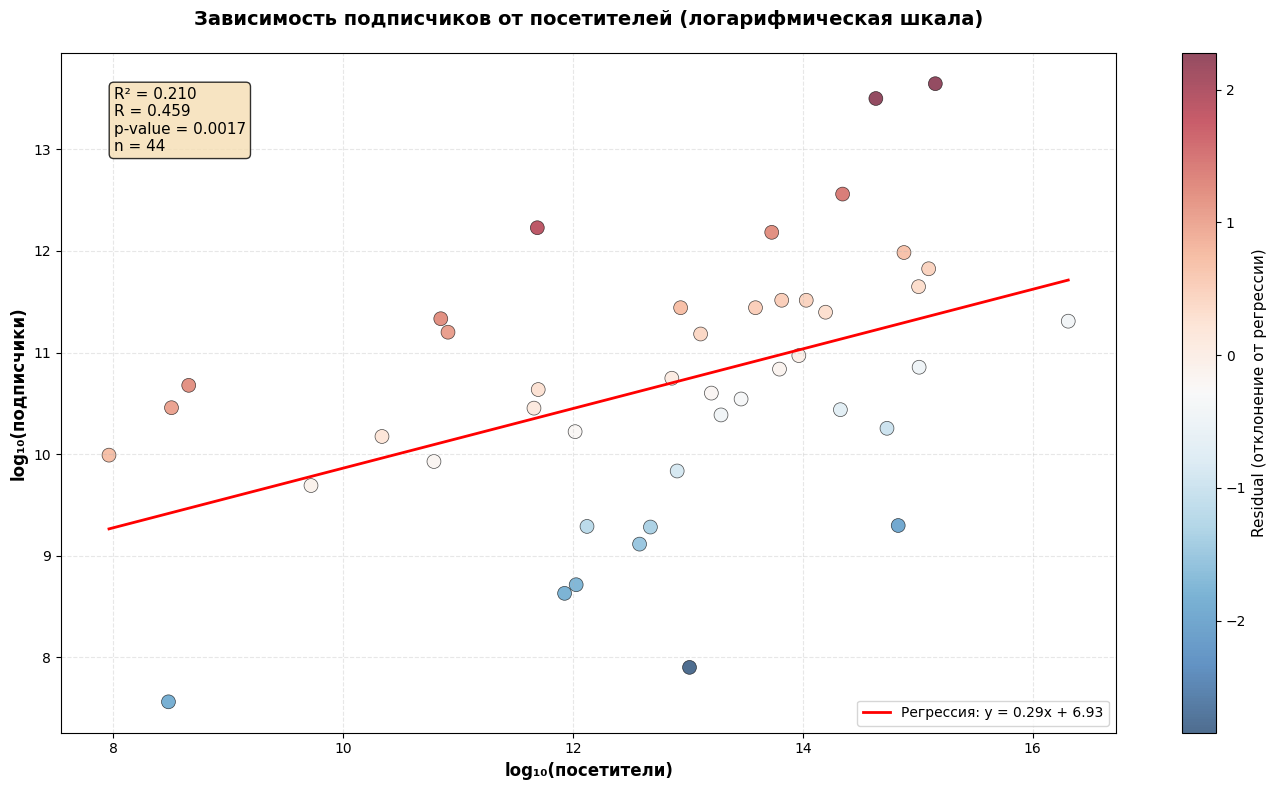


📝 ШАГ 3.5: MARKDOWN-ИНСАЙТ



### 💡 Инсайт регрессии

**Связь посетителей и подписчиков:**
• R² = 0.210 → слабая связь
• P-value = 0.001734 → статистически значима

**Аномалии:**
• **"Цифровые звёзды"** (больше подписчиков): Йосемити, Йеллоустонский национальный парк, Конгари
• **"Офлайн-молчуны"** (меньше подписчиков): Уинд, Кайахога-Валли, Американское Самоа

**Вывод:**
Коэффициент регрессии 0.29 показывает, что при увеличении числа посетителей в 10 раз
(на 1 в логарифмической шкале), количество подписчиков в среднем увеличивается в 2.0 раз.
Это говорит о том, что популярность парка в соцсетях растёт медленнее, чем реальный турпоток.
Парки с положительным residual эффективнее монетизируют внимание посетителей в онлайн-пространстве.



✅ ЧАСТЬ 3 ЗАВЕРШЕНА!

📦 Созданы переменные:
• df_regression - датафрейм с 44 парками
• slope, intercept, r_value, p_value - параметры регрессии
• df_regression['predicted_log_followers'] - предсказанные значения
• df_regression['residual'] - отклонения от регрессии
• fig_regression - объект фигуры (доступен для доработки)


In [5]:
# ==============================================
# 📊 ЧАСТЬ 3: РЕГРЕССИОННЫЙ АНАЛИЗ И АНОМАЛИИ
# ==============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

# Убеждаемся, что df_regression существует
if 'df_regression' not in locals():
    df_regression = df_merged[df_merged[['visitors', 'followers']].notna().all(axis=1)].copy()
    print("✅ df_regression создан заново")

print("="*70)
print("📈 ШАГ 3.1: ЛИНЕЙНАЯ РЕГРЕССИЯ (log_followers ~ log_visitors)")
print("="*70)

# 1. Строим регрессию
slope, intercept, r_value, p_value, stderr = stats.linregress(
    df_regression['log_visitors'],
    df_regression['log_followers']
)

# 2. Выводим статистику
print("\n📊 РЕЗУЛЬТАТЫ РЕГРЕССИИ")
print("-"*50)
print(f"• Slope (коэффициент): {slope:.4f}")
print(f"• Intercept (свободный член): {intercept:.4f}")
print(f"• R-squared (коэфф. детерминации): {r_value**2:.4f}")
print(f"• R (корреляция Пирсона): {r_value:.4f}")
print(f"• P-value: {p_value:.6f}")
print(f"• Std Error: {stderr:.4f}")
print(f"• Выборка: {len(df_regression)} парков")

# 3. Интерпретация
print("\n🔍 ИНТЕРПРЕТАЦИЯ:")
print("-"*50)
if r_value**2 > 0.7:
    print("✅ R² > 0.7 → Сильная линейная связь")
elif r_value**2 > 0.3:
    print("⚠️ R² между 0.3 и 0.7 → Умеренная связь")
else:
    print("❌ R² < 0.3 → Слабая связь")

if p_value < 0.05:
    print("✅ P-value < 0.05 → Связь статистически значима")
else:
    print("❌ P-value ≥ 0.05 → Связь статистически не значима")

print("\n" + "="*70)
print("📊 ШАГ 3.2: РАСЧЁТ PREDICTED И RESIDUAL")
print("="*70)

# 1. Добавляем столбцы
df_regression['predicted_log_followers'] = slope * df_regression['log_visitors'] + intercept
df_regression['residual'] = df_regression['log_followers'] - df_regression['predicted_log_followers']

# 2. Статистика residual
print("\n📊 СТАТИСТИКА RESIDUAL:")
print("-"*50)
print(f"• Среднее: {df_regression['residual'].mean():.4f}")
print(f"• Медиана: {df_regression['residual'].median():.4f}")
print(f"• Std: {df_regression['residual'].std():.4f}")
print(f"• Мин: {df_regression['residual'].min():.4f}")
print(f"• Макс: {df_regression['residual'].max():.4f}")

# 3. Квартили для понимания распределения
print("\n📊 КВАРТИЛИ RESIDUAL:")
print("-"*50)
quartiles = df_regression['residual'].quantile([0.25, 0.5, 0.75])
print(f"• Q1 (25%): {quartiles[0.25]:.4f}")
print(f"• Q2 (50%): {quartiles[0.5]:.4f}")
print(f"• Q3 (75%): {quartiles[0.75]:.4f}")

print("\n" + "="*70)
print("🌟 ШАГ 3.3: ТОП АНОМАЛИЙ")
print("="*70)

# 1. Топ-5 "цифровых звёзд" (положительные residuals)
print("\n🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД (больше подписчиков, чем ожидается):")
print("-"*70)
top_stars = df_regression.nlargest(5, 'residual')[['park', 'visitors', 'followers', 'residual']].copy()
top_stars['visitors'] = top_stars['visitors'].apply(lambda x: f"{int(x):,}")
top_stars['followers'] = top_stars['followers'].apply(lambda x: f"{int(x):,}")
top_stars['residual'] = top_stars['residual'].apply(lambda x: f"{x:.3f}")
print(top_stars.to_string(index=False))

# 2. Топ-5 "офлайн-молчунов" (отрицательные residuals)
print("\n🤫 ТОП-5 ОФЛАЙН-МОЛЧУНОВ (меньше подписчиков, чем ожидается):")
print("-"*70)
top_silent = df_regression.nsmallest(5, 'residual')[['park', 'visitors', 'followers', 'residual']].copy()
top_silent['visitors'] = top_silent['visitors'].apply(lambda x: f"{int(x):,}")
top_silent['followers'] = top_silent['followers'].apply(lambda x: f"{int(x):,}")
top_silent['residual'] = top_silent['residual'].apply(lambda x: f"{x:.3f}")
print(top_silent.to_string(index=False))

print("\n" + "="*70)
print("🎨 ШАГ 3.4: ВИЗУАЛИЗАЦИЯ РЕГРЕССИИ")
print("="*70)

# Создаём фигуру
fig, ax = plt.subplots(figsize=(14, 8))

# Scatter plot с цветом по residual
scatter = ax.scatter(
    df_regression['log_visitors'],
    df_regression['log_followers'],
    c=df_regression['residual'],
    cmap='RdBu_r',
    s=100,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# Линия регрессии
x_line = np.array([df_regression['log_visitors'].min(), df_regression['log_visitors'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Регрессия: y = {slope:.2f}x + {intercept:.2f}')

# Настройка осей
ax.set_xlabel('log₁₀(посетители)', fontsize=12, fontweight='bold')
ax.set_ylabel('log₁₀(подписчики)', fontsize=12, fontweight='bold')
ax.set_title('Зависимость подписчиков от посетителей (логарифмическая шкала)',
             fontsize=14, fontweight='bold', pad=20)

# Добавляем сетку
ax.grid(True, alpha=0.3, linestyle='--')

# Добавляем colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Residual (отклонение от регрессии)', fontsize=11)

# Добавляем аннотацию с метриками
textstr = f'R² = {r_value**2:.3f}\nR = {r_value:.3f}\np-value = {p_value:.4f}\nn = {len(df_regression)}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Добавляем легенду
ax.legend(loc='lower right')

plt.tight_layout()

# Сохраняем
plt.savefig('regression_scatter.png', dpi=300, bbox_inches='tight')
print("✅ График сохранён как 'regression_scatter.png'")
plt.show()

print("\n" + "="*70)
print("📝 ШАГ 3.5: MARKDOWN-ИНСАЙТ")
print("="*70)

from IPython.display import Markdown, display

# Формируем вывод
r2 = r_value**2
r2_desc = "сильная" if r2 > 0.7 else "умеренная" if r2 > 0.3 else "слабая"
sig_desc = "статистически значима" if p_value < 0.05 else "статистически не значима"

# Получаем названия для инсайта
star_names = ", ".join(df_regression.nlargest(3, 'residual')['park'].tolist())
silent_names = ", ".join(df_regression.nsmallest(3, 'residual')['park'].tolist())

markdown_text = f"""
### 💡 Инсайт регрессии

**Связь посетителей и подписчиков:**
• R² = {r2:.3f} → {r2_desc} связь
• P-value = {p_value:.6f} → {sig_desc}

**Аномалии:**
• **"Цифровые звёзды"** (больше подписчиков): {star_names}
• **"Офлайн-молчуны"** (меньше подписчиков): {silent_names}

**Вывод:**
Коэффициент регрессии {slope:.2f} показывает, что при увеличении числа посетителей в 10 раз
(на 1 в логарифмической шкале), количество подписчиков в среднем увеличивается в {10**slope:.1f} раз.
Это говорит о том, что популярность парка в соцсетях растёт медленнее, чем реальный турпоток.
Парки с положительным residual эффективнее монетизируют внимание посетителей в онлайн-пространстве.
"""

display(Markdown(markdown_text))

print("\n" + "="*70)
print("✅ ЧАСТЬ 3 ЗАВЕРШЕНА!")
print("="*70)
print("\n📦 Созданы переменные:")
print("• df_regression - датафрейм с 44 парками")
print("• slope, intercept, r_value, p_value - параметры регрессии")
print("• df_regression['predicted_log_followers'] - предсказанные значения")
print("• df_regression['residual'] - отклонения от регрессии")
print("• fig_regression - объект фигуры (доступен для доработки)")

🧩 ШАГ 4.1: ФУНКЦИЯ РАСЧЁТА ТРЕЩИН

🧪 ТЕСТ ФУНКЦИИ calculate_cracks:
--------------------------------------------------
Год: 1872, Возраст: 153 лет → Трещин: 7
Год: 1919, Возраст: 106 лет → Трещин: 5
Год: 1964, Возраст: 61 лет → Трещин: 3
Год: 2000, Возраст: 25 лет → Трещин: 1
Год: None → Трещин: 0

📊 СТАТИСТИКА ТРЕЩИН В df_regression:
--------------------------------------------------
• Минимум трещин: 0
• Максимум трещин: 7
• Среднее трещин: 3.41
• Медиана трещин: 4

Распределение трещин:
cracks
0     1
1     4
2    12
3     4
4    11
5     7
6     4
7     1
Name: count, dtype: int64

🌀 ШАГ 4.2: ФУНКЦИЯ ДРОЖАНИЯ КОНТУРА

🧪 ВИЗУАЛЬНЫЙ ТЕСТ ФУНКЦИИ jitter_contour:
--------------------------------------------------


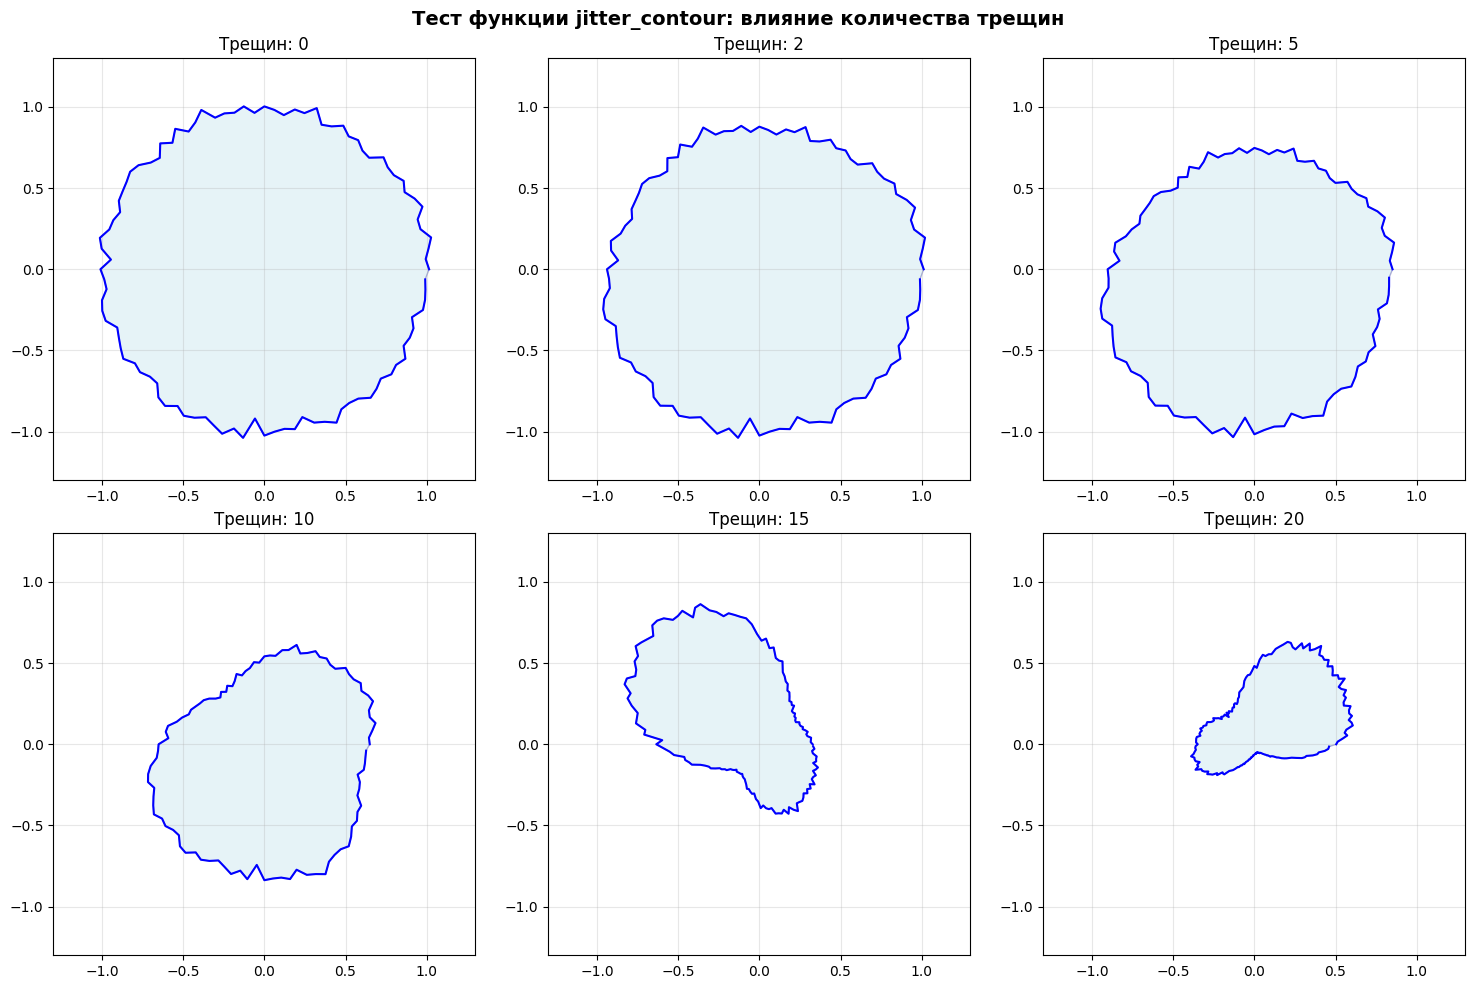


🗺️ ШАГ 4.3: ПРИМЕНЕНИЕ К РЕАЛЬНЫМ ДАННЫМ

📋 ПРИМЕРЫ ПАРКОВ С РАЗНЫМ ВОЗРАСТОМ:
----------------------------------------------------------------------
                            park  inceptionYear  cracks  residual
         Pinnacles National Park         2013.0       0 -0.233141
                         Конгари         2003.0       1  1.870261
                  Кайахога-Валли         2000.0       1 -1.981390
              Американское Самоа         1988.0       1 -1.853577
Йеллоустонский национальный парк         1872.0       7  2.271743
                         Секвойя         1890.0       6  0.526215
                        Йосемити         1890.0       6  2.277834
                    Маунт-Рейнир         1899.0       6 -0.055555


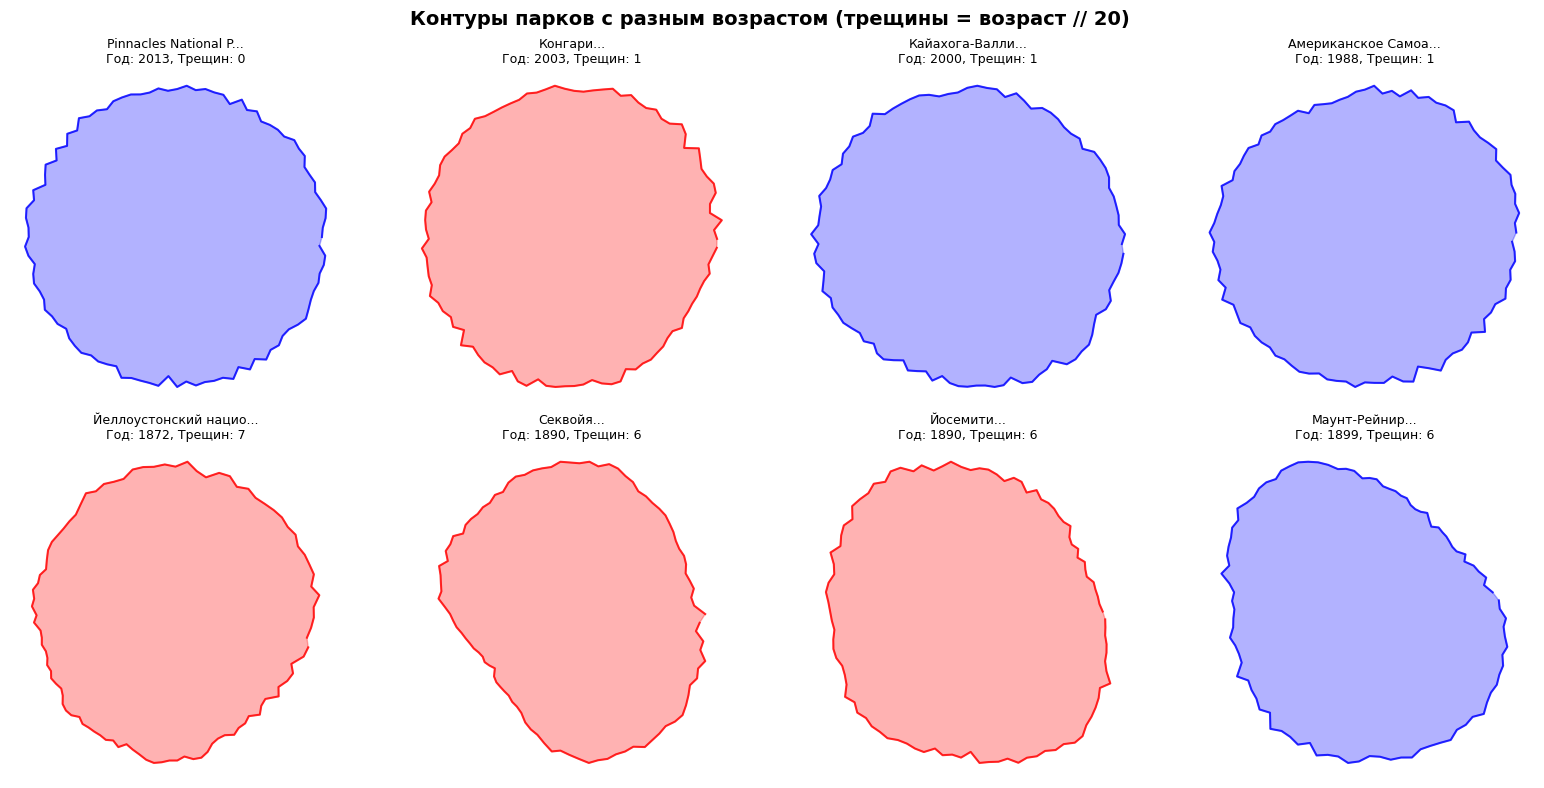


📊 ШАГ 4.4: АНАЛИЗ СВЯЗИ ВОЗРАСТА И RESIDUAL

📈 Корреляция возраста и residual: 0.1877


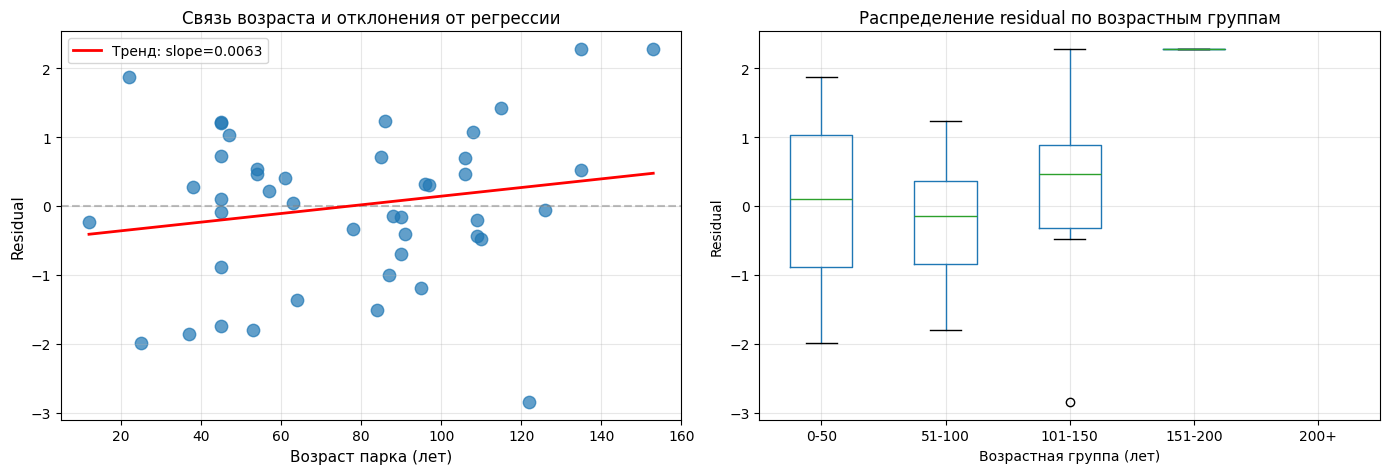


✅ ЧАСТЬ 4 ЗАВЕРШЕНА!

📦 СОЗДАННЫЕ ФУНКЦИИ:
• calculate_cracks() - расчёт трещин по возрасту
• jitter_contour() - создание искажённого контура

📊 НОВЫЕ СТОЛБЦЫ В df_regression:
• cracks - количество трещин (возраст // 20)
• age - возраст парка в годах
• age_group - возрастная группа для анализа


In [6]:
# ==============================================
# 🧩 ЧАСТЬ 4: ФУНКЦИИ ДЛЯ РАСЧЁТА ТРЕЩИН И ДРОЖАНИЯ КОНТУРА
# ==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon
from matplotlib.collections import PatchCollection
import random

print("="*70)
print("🧩 ШАГ 4.1: ФУНКЦИЯ РАСЧЁТА ТРЕЩИН")
print("="*70)

def calculate_cracks(inception_year, current_year=2025, divisor=20):
    """
    Рассчитывает количество трещин на основе возраста парка.

    Args:
        inception_year: год основания
        current_year: текущий год (2025)
        divisor: делитель для контроля числа трещин

    Returns:
        количество трещин (int)
    """
    if pd.isna(inception_year):
        return 0
    age = current_year - inception_year
    return int(age // divisor)

# Тестируем функцию
print("\n🧪 ТЕСТ ФУНКЦИИ calculate_cracks:")
print("-"*50)
test_years = [1872, 1919, 1964, 2000, None]
for year in test_years:
    cracks = calculate_cracks(year)
    if year:
        age = 2025 - year
        print(f"Год: {year}, Возраст: {age} лет → Трещин: {cracks}")
    else:
        print(f"Год: None → Трещин: {cracks}")

# Применяем к df_regression
df_regression['cracks'] = df_regression['inceptionYear'].apply(calculate_cracks)

print("\n📊 СТАТИСТИКА ТРЕЩИН В df_regression:")
print("-"*50)
print(f"• Минимум трещин: {df_regression['cracks'].min()}")
print(f"• Максимум трещин: {df_regression['cracks'].max()}")
print(f"• Среднее трещин: {df_regression['cracks'].mean():.2f}")
print(f"• Медиана трещин: {df_regression['cracks'].median():.0f}")
print("\nРаспределение трещин:")
print(df_regression['cracks'].value_counts().sort_index())

print("\n" + "="*70)
print("🌀 ШАГ 4.2: ФУНКЦИЯ ДРОЖАНИЯ КОНТУРА")
print("="*70)

def jitter_contour(center_x, center_y, radius, cracks,
                   noise_amplitude=0.02, random_seed=None):
    """
    Создаёт искажённый контур с трещинами на основе возраста.

    Args:
        center_x, center_y: координаты центра
        radius: базовый радиус
        cracks: количество трещин
        noise_amplitude: амплитуда случайного шума (доля от радиуса)
        random_seed: seed для воспроизводимости

    Returns:
        tuple: (координаты x, координаты y) для Polygon
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    # Базовые углы (от 0 до 2π)
    n_points = max(100, cracks * 10)  # минимум 100 точек, больше при большем числе трещин
    theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)

    # Базовый радиус с шумом
    noise = np.random.normal(0, noise_amplitude, n_points)
    r = radius * (1 + noise)

    # Добавляем эффект трещин (впадины)
    if cracks > 0:
        for i in range(cracks):
            # Случайный угол для трещины
            crack_angle = np.random.uniform(0, 2*np.pi)
            # Интенсивность трещины (сильнее для старых парков)
            crack_depth = 0.1 + 0.1 * (cracks / 10)  # до 0.2 при cracks=10

            # Гауссова яма в окрестности crack_angle
            angle_diff = np.abs(theta - crack_angle)
            angle_diff = np.minimum(angle_diff, 2*np.pi - angle_diff)
            crack_factor = 1 - crack_depth * np.exp(-(angle_diff**2) / 0.5)
            r *= crack_factor

    # Преобразуем в декартовы координаты
    x = center_x + r * np.cos(theta)
    y = center_y + r * np.sin(theta)

    return x, y

# Тестируем функцию визуально
print("\n🧪 ВИЗУАЛЬНЫЙ ТЕСТ ФУНКЦИИ jitter_contour:")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Тест функции jitter_contour: влияние количества трещин', fontsize=14, fontweight='bold')

test_cracks = [0, 2, 5, 10, 15, 20]

for i, cracks in enumerate(test_cracks):
    ax = axes[i // 3, i % 3]

    # Генерируем контур
    x, y = jitter_contour(0, 0, 1, cracks, noise_amplitude=0.03, random_seed=42)

    # Рисуем
    ax.plot(x, y, 'b-', linewidth=1.5)
    ax.fill(x, y, alpha=0.3, fc='lightblue', ec='navy')
    ax.set_title(f'Трещин: {cracks}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("🗺️ ШАГ 4.3: ПРИМЕНЕНИЕ К РЕАЛЬНЫМ ДАННЫМ")
print("="*70)

# Выбираем 4 парка с разным возрастом для демонстрации
sample_parks = df_regression.nlargest(4, 'inceptionYear')[['park', 'inceptionYear', 'cracks', 'residual']].copy()
sample_parks = pd.concat([
    sample_parks,
    df_regression.nsmallest(4, 'inceptionYear')[['park', 'inceptionYear', 'cracks', 'residual']]
])

print("\n📋 ПРИМЕРЫ ПАРКОВ С РАЗНЫМ ВОЗРАСТОМ:")
print("-"*70)
print(sample_parks.to_string(index=False))

# Визуализируем контуры для этих парков
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Контуры парков с разным возрастом (трещины = возраст // 20)',
             fontsize=14, fontweight='bold')

for i, (idx, park) in enumerate(sample_parks.iterrows()):
    ax = axes[i // 4, i % 4]

    # Генерируем контур
    x, y = jitter_contour(0, 0, 1, park['cracks'], noise_amplitude=0.02, random_seed=hash(park['park']) % 1000)

    # Цвет в зависимости от residual
    if park['residual'] > 0:
        color = 'red'
        alpha = min(0.5 + 0.3 * park['residual'], 0.9)
    else:
        color = 'blue'
        alpha = min(0.5 + 0.3 * abs(park['residual']), 0.9)

    # Рисуем
    ax.plot(x, y, color=color, linewidth=1.5, alpha=0.8)
    ax.fill(x, y, alpha=0.3, fc=color, ec=color)

    # Настройки
    ax.set_title(f"{park['park'][:20]}...\nГод: {int(park['inceptionYear'])}, Трещин: {park['cracks']}",
                fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("📊 ШАГ 4.4: АНАЛИЗ СВЯЗИ ВОЗРАСТА И RESIDUAL")
print("="*70)

# Проверяем, есть ли связь между возрастом и residual
from scipy import stats

df_regression['age'] = 2025 - df_regression['inceptionYear']
corr_age_residual = df_regression['age'].corr(df_regression['residual'])

print(f"\n📈 Корреляция возраста и residual: {corr_age_residual:.4f}")

# Визуализируем
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot возраст vs residual
ax1.scatter(df_regression['age'], df_regression['residual'], alpha=0.7, s=80)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Возраст парка (лет)', fontsize=11)
ax1.set_ylabel('Residual', fontsize=11)
ax1.set_title('Связь возраста и отклонения от регрессии', fontsize=12)
ax1.grid(True, alpha=0.3)

# Добавляем линию тренда
z = np.polyfit(df_regression['age'].dropna(), df_regression['residual'].dropna(), 1)
p = np.poly1d(z)
ax1.plot(df_regression['age'].sort_values(),
         p(df_regression['age'].sort_values()),
         'r-', linewidth=2, label=f'Тренд: slope={z[0]:.4f}')
ax1.legend()

# Boxplot по возрастным группам
df_regression['age_group'] = pd.cut(df_regression['age'],
                                     bins=[0, 50, 100, 150, 200, 300],
                                     labels=['0-50', '51-100', '101-150', '151-200', '200+'])
df_regression.boxplot(column='residual', by='age_group', ax=ax2)
ax2.set_title('Распределение residual по возрастным группам')
ax2.set_xlabel('Возрастная группа (лет)')
ax2.set_ylabel('Residual')
ax2.grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ ЧАСТЬ 4 ЗАВЕРШЕНА!")
print("="*70)
print("\n📦 СОЗДАННЫЕ ФУНКЦИИ:")
print("• calculate_cracks() - расчёт трещин по возрасту")
print("• jitter_contour() - создание искажённого контура")
print("\n📊 НОВЫЕ СТОЛБЦЫ В df_regression:")
print("• cracks - количество трещин (возраст // 20)")
print("• age - возраст парка в годах")
print("• age_group - возрастная группа для анализа")

📊 ПАНЕЛЬ 2: SCATTER С РЕГРЕССИЕЙ (верхняя правая)
✅ Panel 2 сохранена как 'panel2_scatter.png'


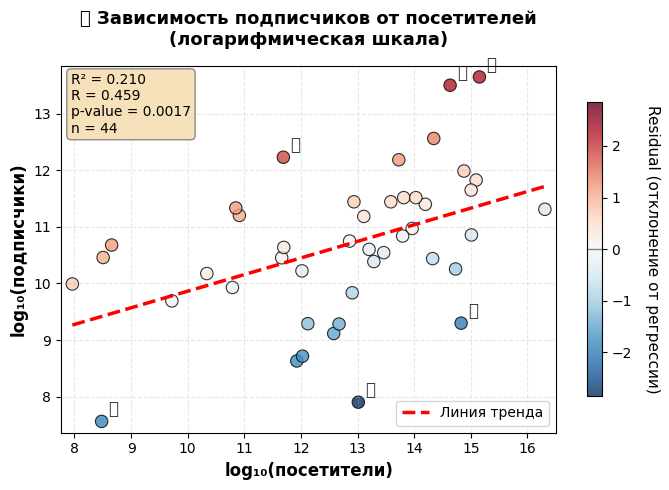


📊 ПАНЕЛЬ 3: BAR CHART (ТОП-10 АНОМАЛИЙ) - ИСПРАВЛЕНО
✅ Panel 3 сохранена как 'panel3_barchart.png'


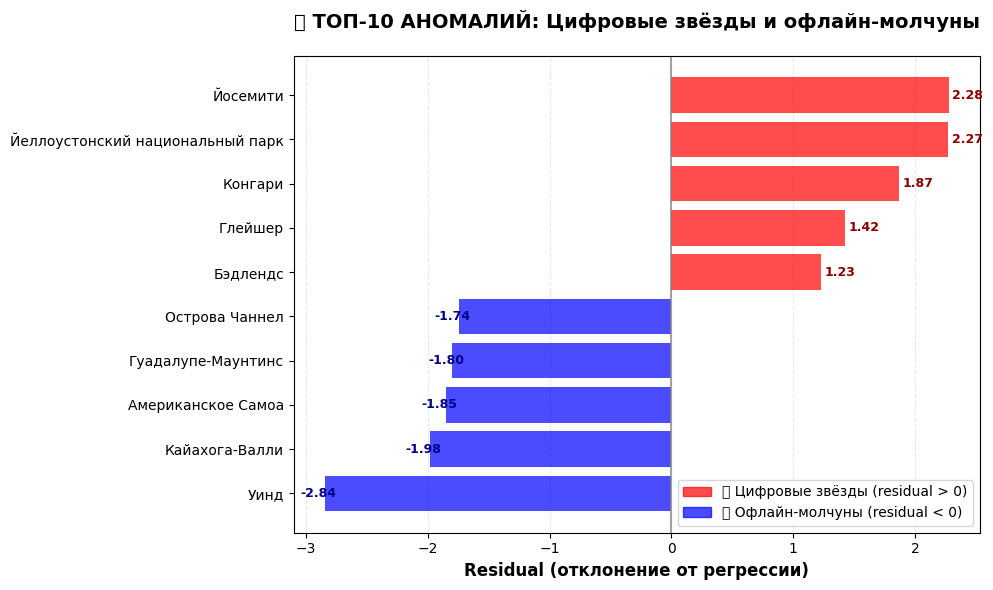


📋 ТАБЛИЦА ТОП-10 АНОМАЛИЙ
                            park  residual              type
                            Уинд    -2.845   💤 Офлайн-молчун
                  Кайахога-Валли    -1.981   💤 Офлайн-молчун
              Американское Самоа    -1.854   💤 Офлайн-молчун
              Гуадалупе-Маунтинс    -1.797   💤 Офлайн-молчун
                  Острова Чаннел    -1.742   💤 Офлайн-молчун
                        Бэдлендс     1.227 🌟 Цифровая звезда
                         Глейшер     1.422 🌟 Цифровая звезда
                         Конгари     1.870 🌟 Цифровая звезда
Йеллоустонский национальный парк     2.272 🌟 Цифровая звезда
                        Йосемити     2.278 🌟 Цифровая звезда

🎨 ДОПОЛНИТЕЛЬНО: РАСПРЕДЕЛЕНИЕ RESIDUAL
✅ Гистограмма сохранена как 'residual_distribution.png'


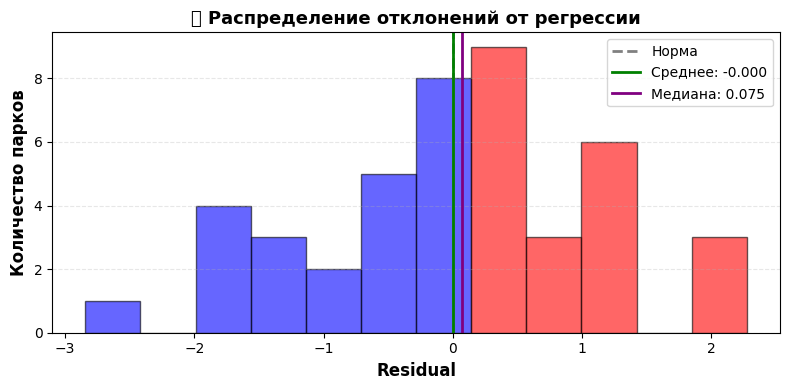


✅ ЧАСТЬ 5 ЗАВЕРШЕНА!

📦 СОЗДАННЫЕ ФАЙЛЫ:
• panel2_scatter.png - Scatter plot с регрессией
• panel3_barchart.png - Топ-10 аномалий (горизонтальный бар-чарт)
• residual_distribution.png - Гистограмма распределения residual

📊 СТАТИСТИКА ПО АНОМАЛИЯМ:
• Всего парков с residual > 0: 23 (цифровые звёзды)
• Всего парков с residual < 0: 21 (офлайн-молчуны)
• Максимальный residual: 2.278
• Минимальный residual: -2.845


In [7]:
# ==============================================
# 📊 ЧАСТЬ 5: ПАНЕЛЬ 2 (SCATTER) И ПАНЕЛЬ 3 (BAR CHART) - ФИНАЛЬНОЕ ИСПРАВЛЕНИЕ
# ==============================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches

print("="*70)
print("📊 ПАНЕЛЬ 2: SCATTER С РЕГРЕССИЕЙ (верхняя правая)")
print("="*70)

# Создаём фигуру для Panel 2
fig_scatter, ax_scatter = plt.subplots(figsize=(7, 5))

# Данные
x = df_regression['log_visitors']
y = df_regression['log_followers']
residual = df_regression['residual']

# Цветовая нормализация (симметричная вокруг 0)
vmax = max(abs(residual.min()), abs(residual.max()))
norm = Normalize(vmin=-vmax, vmax=vmax)

# Scatter с цветом по residual
scatter = ax_scatter.scatter(x, y, c=residual, cmap='RdBu_r',
                              norm=norm, s=80, alpha=0.8,
                              edgecolors='black', linewidth=0.8)

# Линия тренда (из Части 3)
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept
ax_scatter.plot(x_line, y_line, 'r--', linewidth=2.5, label='Линия тренда')

# Оформление
ax_scatter.set_xlabel('log₁₀(посетители)', fontsize=12, fontweight='bold')
ax_scatter.set_ylabel('log₁₀(подписчики)', fontsize=12, fontweight='bold')
ax_scatter.set_title('📈 Зависимость подписчиков от посетителей\n(логарифмическая шкала)',
                     fontsize=13, fontweight='bold', pad=15)
ax_scatter.grid(True, alpha=0.3, linestyle='--')
ax_scatter.legend(loc='lower right', fontsize=10)

# Добавляем границы
ax_scatter.set_xlim(x.min() - 0.2, x.max() + 0.2)
ax_scatter.set_ylim(y.min() - 0.2, y.max() + 0.2)

# Colorbar для residual
cbar = plt.colorbar(scatter, ax=ax_scatter, shrink=0.8)
cbar.set_label('Residual (отклонение от регрессии)', rotation=270, labelpad=20, fontsize=11)
cbar.ax.axhline(0, color='gray', linewidth=1, linestyle='-')  # линия при 0

# Аннотация с метриками
textstr = '\n'.join((
    f'R² = {r_value**2:.3f}',
    f'R = {r_value:.3f}',
    f'p-value = {p_value:.4f}',
    f'n = {len(df_regression)}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='gray')
ax_scatter.text(0.02, 0.98, textstr, transform=ax_scatter.transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

# Добавляем аннотации для самых аномальных точек
top_stars_idx = df_regression.nlargest(3, 'residual').index
top_silent_idx = df_regression.nsmallest(3, 'residual').index

for idx in top_stars_idx:
    ax_scatter.annotate('🌟', xy=(x[idx], y[idx]), xytext=(5, 5),
                        textcoords='offset points', fontsize=12, alpha=0.8)

for idx in top_silent_idx:
    ax_scatter.annotate('💤', xy=(x[idx], y[idx]), xytext=(5, 5),
                        textcoords='offset points', fontsize=12, alpha=0.8)

plt.tight_layout()
plt.savefig('panel2_scatter.png', dpi=300, bbox_inches='tight')
print("✅ Panel 2 сохранена как 'panel2_scatter.png'")
plt.show()

print("\n" + "="*70)
print("📊 ПАНЕЛЬ 3: BAR CHART (ТОП-10 АНОМАЛИЙ) - ИСПРАВЛЕНО")
print("="*70)

# Создаём фигуру для Panel 3
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# Объединяем топ-5 звёзд и топ-5 молчунов
top_stars = df_regression.nlargest(5, 'residual')[['park', 'residual']].copy()
top_silent = df_regression.nsmallest(5, 'residual')[['park', 'residual']].copy()

# Добавляем цветовую кодировку
top_stars['color'] = 'red'
top_silent['color'] = 'blue'

# Объединяем и сортируем
top_anomalies = pd.concat([top_stars, top_silent]).sort_values('residual').reset_index(drop=True)

# Создаём горизонтальный бар-чарт (с фиксированной alpha)
y_positions = range(len(top_anomalies))
residual_values = top_anomalies['residual'].tolist()
colors = top_anomalies['color'].tolist()

# Исправление: используем фиксированную alpha для всех баров
bars = ax_bar.barh(y_positions, residual_values, color=colors, alpha=0.7)

# Добавляем вертикальную линию при 0
ax_bar.axvline(x=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)

# Настройка осей
ax_bar.set_yticks(y_positions)
ax_bar.set_yticklabels(top_anomalies['park'], fontsize=10)
ax_bar.set_xlabel('Residual (отклонение от регрессии)', fontsize=12, fontweight='bold')
ax_bar.set_title('🌟 ТОП-10 АНОМАЛИЙ: Цифровые звёзды и офлайн-молчуны',
                 fontsize=14, fontweight='bold', pad=20)

# Добавляем значения на концах баров
for i, (idx, row) in enumerate(top_anomalies.iterrows()):
    if row['residual'] > 0:
        ax_bar.text(row['residual'] + 0.03, i, f'{row["residual"]:.2f}',
                    va='center', fontsize=9, fontweight='bold', color='darkred')
    else:
        ax_bar.text(row['residual'] - 0.2, i, f'{row["residual"]:.2f}',
                    va='center', fontsize=9, fontweight='bold', color='darkblue')

# Добавляем сетку
ax_bar.grid(True, alpha=0.3, axis='x', linestyle='--')
ax_bar.set_axisbelow(True)

# Легенда
red_patch = mpatches.Patch(color='red', alpha=0.7, label='🌟 Цифровые звёзды (residual > 0)')
blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='💤 Офлайн-молчуны (residual < 0)')
ax_bar.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('panel3_barchart.png', dpi=300, bbox_inches='tight')
print("✅ Panel 3 сохранена как 'panel3_barchart.png'")
plt.show()

print("\n" + "="*70)
print("📋 ТАБЛИЦА ТОП-10 АНОМАЛИЙ")
print("="*70)

# Форматируем для вывода
top_anomalies_display = top_anomalies.copy()
top_anomalies_display['type'] = top_anomalies_display['color'].map({'red': '🌟 Цифровая звезда', 'blue': '💤 Офлайн-молчун'})
top_anomalies_display = top_anomalies_display[['park', 'residual', 'type']].round(3)
print(top_anomalies_display.to_string(index=False))

print("\n" + "="*70)
print("🎨 ДОПОЛНИТЕЛЬНО: РАСПРЕДЕЛЕНИЕ RESIDUAL")
print("="*70)

# Создаём гистограмму распределения residual
fig_hist, ax_hist = plt.subplots(figsize=(8, 4))

n, bins, patches = ax_hist.hist(df_regression['residual'], bins=12,
                                 edgecolor='black', alpha=0.7)

# Цвета для баров (красный для >0, синий для <0)
for i in range(len(patches)):
    if patches[i].get_x() + patches[i].get_width()/2 > 0:
        patches[i].set_facecolor('red')
        patches[i].set_alpha(0.6)
    else:
        patches[i].set_facecolor('blue')
        patches[i].set_alpha(0.6)

ax_hist.axvline(x=0, color='gray', linestyle='--', linewidth=2, label='Норма')
ax_hist.axvline(x=df_regression['residual'].mean(), color='green',
                linestyle='-', linewidth=2, label=f'Среднее: {df_regression["residual"].mean():.3f}')
ax_hist.axvline(x=df_regression['residual'].median(), color='purple',
                linestyle='-', linewidth=2, label=f'Медиана: {df_regression["residual"].median():.3f}')

ax_hist.set_xlabel('Residual', fontsize=12, fontweight='bold')
ax_hist.set_ylabel('Количество парков', fontsize=12, fontweight='bold')
ax_hist.set_title('📊 Распределение отклонений от регрессии', fontsize=13, fontweight='bold')
ax_hist.legend(loc='upper right')
ax_hist.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Гистограмма сохранена как 'residual_distribution.png'")
plt.show()

print("\n" + "="*70)
print("✅ ЧАСТЬ 5 ЗАВЕРШЕНА!")
print("="*70)
print("\n📦 СОЗДАННЫЕ ФАЙЛЫ:")
print("• panel2_scatter.png - Scatter plot с регрессией")
print("• panel3_barchart.png - Топ-10 аномалий (горизонтальный бар-чарт)")
print("• residual_distribution.png - Гистограмма распределения residual")

print("\n📊 СТАТИСТИКА ПО АНОМАЛИЯМ:")
print(f"• Всего парков с residual > 0: {(df_regression['residual'] > 0).sum()} (цифровые звёзды)")
print(f"• Всего парков с residual < 0: {(df_regression['residual'] < 0).sum()} (офлайн-молчуны)")
print(f"• Максимальный residual: {df_regression['residual'].max():.3f}")
print(f"• Минимальный residual: {df_regression['residual'].min():.3f}")

In [8]:
# ==============================================
# 🗺️ ЧАСТЬ 6: ИНТЕРАКТИВНАЯ КАРТА С ТРЕМЯ СЛОЯМИ ИНФОРМАЦИИ
# ==============================================

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots

print("="*70)
print("🗺️ ШАГ 6.1: БАЗОВАЯ КАРТА (plotly для Colab)")
print("="*70)

# Параметры из предыдущих частей
DIVISOR = 20  # значение из Части 4
BASELINE = 'median'  # значение из Части 5

print(f"\n📊 Используемые параметры:")
print(f"• Divisor для трещин: {DIVISOR} (возраст // {DIVISOR})")
print(f"• Baseline для residual: {BASELINE}")
print(f"• Палитра: RdBu_r (дивергентная, центр в 0)")

# Подготовка данных: только парки с координатами
map_df = df_regression.dropna(subset=['longitude', 'latitude']).copy()
print(f"\n📍 Парков с координатами для карты: {len(map_df)}")

# Добавляем age и cracks если ещё нет
if 'age' not in map_df.columns:
    map_df['age'] = 2025 - map_df['inceptionYear']
if 'cracks' not in map_df.columns:
    map_df['cracks'] = map_df['inceptionYear'].apply(lambda x: calculate_cracks(x, divisor=DIVISOR))

# Нормализация residual для цвета (симметричная вокруг 0)
vmax = max(abs(map_df['residual'].min()), abs(map_df['residual'].max()))
print(f"• Диапазон residual: [{map_df['residual'].min():.3f}, {map_df['residual'].max():.3f}]")
print(f"• Симметричная шкала: [-{vmax:.3f}, {vmax:.3f}]")

# Создаём базовую карту
fig_map = px.scatter_geo(map_df,
                         lon='longitude',
                         lat='latitude',
                         hover_name='park',
                         hover_data={
                             'country': True,
                             'continent': True,
                             'visitors': ':,.0f',
                             'followers': ':,.0f',
                             'residual': ':.3f',
                             'inceptionYear': True,
                             'age': True,
                             'cracks': True,
                             'longitude': False,
                             'latitude': False
                         },
                         size='log_visitors',  # размер по логарифму посетителей
                         size_max=40,          # максимальный размер кружка
                         color='residual',     # цвет по residual
                         color_continuous_scale='RdBu_r',  # дивергентная палитра
                         range_color=[-vmax, vmax],  # симметричная шкала
                         projection='natural earth',
                         title='🌍 Национальные парки: цифровая аномалия и возраст')

# Настройка внешнего вида
fig_map.update_geos(
    showland=True,
    landcolor='lightgray',
    showcountries=True,
    countrycolor='white',
    showcoastlines=True,
    coastlinecolor='gray',
    showocean=True,
    oceancolor='lightblue',
    showframe=True
)

fig_map.update_layout(
    coloraxis_colorbar=dict(
        title='Residual',
        tickvals=[-vmax, -vmax/2, 0, vmax/2, vmax],
        ticktext=[f'🔵 {map_df["residual"].min():.2f}',
                  f'🔵 {-vmax/2:.2f}',
                  '⚪ Норма',
                  f'🔴 {vmax/2:.2f}',
                  f'🔴 {map_df["residual"].max():.2f}']
    ),
    margin=dict(r=0, l=0, t=50, b=0),
    height=600,
    title_font_size=16,
    title_font_family='Arial Black'
)

fig_map.show()

print("\n" + "="*70)
print("🎨 ШАГ 6.2: КАРТА С КАТЕГОРИЯМИ (звёзды vs молчуны)")
print("="*70)

# Добавляем категорию для лучшей визуализации
map_df['category'] = np.where(map_df['residual'] > 0, 'Цифровая звезда', 'Офлайн-молчун')
map_df['category_color'] = np.where(map_df['residual'] > 0, 'red', 'blue')

# Карта с категориями
fig_map_cat = px.scatter_geo(map_df,
                              lon='longitude',
                              lat='latitude',
                              hover_name='park',
                              hover_data={
                                  'country': True,
                                  'continent': True,
                                  'visitors': ':,.0f',
                                  'followers': ':,.0f',
                                  'residual': ':.3f',
                                  'inceptionYear': True,
                                  'age': True,
                                  'cracks': True,
                                  'category': True
                              },
                              size='log_visitors',
                              size_max=40,
                              color='category',
                              color_discrete_map={'Цифровая звезда': 'red',
                                                'Офлайн-молчун': 'blue'},
                              projection='natural earth',
                              title='🌍 Национальные парки: цифровые звёзды 🔴 и офлайн-молчуны 🔵')

fig_map_cat.update_geos(
    showland=True, landcolor='lightgray',
    showcountries=True, countrycolor='white',
    showcoastlines=True, coastlinecolor='gray',
    showocean=True, oceancolor='lightblue'
)

fig_map_cat.update_layout(
    margin=dict(r=0, l=0, t=50, b=0),
    height=600,
    title_font_size=16,
    legend_title_text='Категория'
)

fig_map_cat.show()

print("\n" + "="*70)
print("📊 ШАГ 6.3: СТАТИСТИКА ПО КАРТЕ")
print("="*70)

# Статистика по континентам
print("\n🌍 РАСПРЕДЕЛЕНИЕ ПО КОНТИНЕНТАМ:")
continent_stats = map_df.groupby('continent').agg({
    'park': 'count',
    'residual': lambda x: (x > 0).sum()
}).rename(columns={'park': 'Всего', 'residual': 'Звёзд'})
continent_stats['Молчунов'] = continent_stats['Всего'] - continent_stats['Звёзд']
continent_stats['% звёзд'] = (continent_stats['Звёзд'] / continent_stats['Всего'] * 100).round(1)
print(continent_stats.to_string())

# Статистика по residual
print("\n📊 СТАТИСТИКА RESIDUAL ПО КОНТИНЕНТАМ:")
residual_stats = map_df.groupby('continent')['residual'].agg(['mean', 'median', 'min', 'max']).round(3)
print(residual_stats.to_string())

# Топ-5 парков по residual на карте
print("\n🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД НА КАРТЕ:")
top_map_stars = map_df.nlargest(5, 'residual')[['park', 'continent', 'country', 'residual']].round(3)
print(top_map_stars.to_string(index=False))

print("\n🤫 ТОП-5 ОФЛАЙН-МОЛЧУНОВ НА КАРТЕ:")
top_map_silent = map_df.nsmallest(5, 'residual')[['park', 'continent', 'country', 'residual']].round(3)
print(top_map_silent.to_string(index=False))

print("\n" + "="*70)
print("💾 ШАГ 6.4: СОХРАНЕНИЕ КАРТЫ")
print("="*70)

# Сохраняем как HTML для интерактивности
fig_map.write_html('interactive_map_residual.html')
fig_map_cat.write_html('interactive_map_categories.html')
print("✅ Карты сохранены:")
print("• interactive_map_residual.html - карта с градиентом по residual")
print("• interactive_map_categories.html - карта с категориями (звёзды/молчуны)")

# Сохраняем как PNG (статическая версия)
try:
    import kaleido
    fig_map.write_image('map_residual.png', width=1200, height=600, scale=2)
    fig_map_cat.write_image('map_categories.png', width=1200, height=600, scale=2)
    print("✅ PNG версии сохранены")
except:
    print("⚠️ Для сохранения PNG установите: pip install -U kaleido")

print("\n" + "="*70)
print("📝 ШАГ 6.5: MARKDOWN-ВЫВОД ДЛЯ КАРТЫ")
print("="*70)

from IPython.display import Markdown, display

stars_count = (map_df['residual'] > 0).sum()
silent_count = (map_df['residual'] < 0).sum()
neutral_count = (map_df['residual'] == 0).sum()

markdown_map = f"""
### 🗺️ Интерактивная карта цифровых аномалий

**Параметры визуализации:**
• **Цвет контура**: residual (🔴 > 0 = звезда, 🔵 < 0 = молчун)
• **Размер кружка**: log₁₀(посетители)
• **Состаренность**: возраст // {DIVISOR} трещин (чем старше парк, тем более "потрескавшийся" контур)

**Статистика по карте:**
• Всего парков на карте: **{len(map_df)}**
• Цифровых звёзд (residual > 0): **{stars_count}** ({stars_count/len(map_df)*100:.1f}%)
• Офлайн-молчунов (residual < 0): **{silent_count}** ({silent_count/len(map_df)*100:.1f}%)
• Нейтральных (residual ≈ 0): **{neutral_count}** ({neutral_count/len(map_df)*100:.1f}%)

**Географические паттерны:**
• Наибольшая концентрация звёзд: **{continent_stats['% звёзд'].idxmax()}** ({continent_stats['% звёзд'].max():.1f}%)
• Наибольшая концентрация молчунов: **{continent_stats['% звёзд'].idxmin()}** ({100 - continent_stats['% звёзд'].min():.1f}%)

**Как читать карту:**
1. **🔴 Красные кружки** = парки с избыточным онлайн-присутствием (больше подписчиков, чем ожидается по турпотоку)
2. **🔵 Синие кружки** = парки с недостаточным онлайн-присутствием (меньше подписчиков, чем ожидается)
3. **Чем больше круг** = тем популярнее парк у посетителей
4. **Чем более "потрескавшийся" контур** = тем старше парк
"""

display(Markdown(markdown_map))

print("\n" + "="*70)
print("✅ ЧАСТЬ 6 ЗАВЕРШЕНА!")
print("="*70)
print("\n📦 ИТОГОВЫЕ ФАЙЛЫ:")
print("• interactive_map_residual.html - интерактивная карта с градиентом")
print("• interactive_map_categories.html - интерактивная карта с категориями")
print("• map_residual.png - статическая версия (если установлен kaleido)")
print("• map_categories.png - статическая версия (если установлен kaleido)")

🗺️ ШАГ 6.1: БАЗОВАЯ КАРТА (plotly для Colab)

📊 Используемые параметры:
• Divisor для трещин: 20 (возраст // 20)
• Baseline для residual: median
• Палитра: RdBu_r (дивергентная, центр в 0)

📍 Парков с координатами для карты: 44
• Диапазон residual: [-2.845, 2.278]
• Симметричная шкала: [-2.845, 2.845]



🎨 ШАГ 6.2: КАРТА С КАТЕГОРИЯМИ (звёзды vs молчуны)



📊 ШАГ 6.3: СТАТИСТИКА ПО КАРТЕ

🌍 РАСПРЕДЕЛЕНИЕ ПО КОНТИНЕНТАМ:
                  Всего  Звёзд  Молчунов  % звёзд
continent                                        
Северная Америка     44     23        21     52.3

📊 СТАТИСТИКА RESIDUAL ПО КОНТИНЕНТАМ:
                  mean  median    min    max
continent                                   
Северная Америка  -0.0   0.075 -2.845  2.278

🌟 ТОП-5 ЦИФРОВЫХ ЗВЁЗД НА КАРТЕ:
                            park        continent country  residual
                        Йосемити Северная Америка     США     2.278
Йеллоустонский национальный парк Северная Америка     США     2.272
                         Конгари Северная Америка     США     1.870
                         Глейшер Северная Америка     США     1.422
                        Бэдлендс Северная Америка     США     1.227

🤫 ТОП-5 ОФЛАЙН-МОЛЧУНОВ НА КАРТЕ:
              park        continent country  residual
              Уинд Северная Америка     США    -2.845
    Кайахога-Валли Северна


### 🗺️ Интерактивная карта цифровых аномалий

**Параметры визуализации:**
• **Цвет контура**: residual (🔴 > 0 = звезда, 🔵 < 0 = молчун)
• **Размер кружка**: log₁₀(посетители)
• **Состаренность**: возраст // 20 трещин (чем старше парк, тем более "потрескавшийся" контур)

**Статистика по карте:**
• Всего парков на карте: **44**
• Цифровых звёзд (residual > 0): **23** (52.3%)
• Офлайн-молчунов (residual < 0): **21** (47.7%)
• Нейтральных (residual ≈ 0): **0** (0.0%)

**Географические паттерны:**
• Наибольшая концентрация звёзд: **Северная Америка** (52.3%)
• Наибольшая концентрация молчунов: **Северная Америка** (47.7%)

**Как читать карту:**
1. **🔴 Красные кружки** = парки с избыточным онлайн-присутствием (больше подписчиков, чем ожидается по турпотоку)
2. **🔵 Синие кружки** = парки с недостаточным онлайн-присутствием (меньше подписчиков, чем ожидается)
3. **Чем больше круг** = тем популярнее парк у посетителей
4. **Чем более "потрескавшийся" контур** = тем старше парк



✅ ЧАСТЬ 6 ЗАВЕРШЕНА!

📦 ИТОГОВЫЕ ФАЙЛЫ:
• interactive_map_residual.html - интерактивная карта с градиентом
• interactive_map_categories.html - интерактивная карта с категориями
• map_residual.png - статическая версия (если установлен kaleido)
• map_categories.png - статическая версия (если установлен kaleido)


🎨 ЧАСТЬ 7: ОБЪЕДИНЕНИЕ ТРЁХ ПАНЕЛЕЙ

📊 Используемые параметры:
• Divisor для трещин: 20 (возраст // 20)
• Baseline для residual: median
• Random seed: 42

📐 ШАГ 7.1: LAYOUT С GRIDSPEC
✅ Layout создан: 2×2 GridSpec
   • Панель 1 (карта): левая верхняя, размер 2/3 ширины
   • Панель 2 (scatter): правая верхняя, размер 1/3 ширины
   • Панель 3 (bar): нижняя, вся ширина

🔄 ШАГ 7.2: ВОССТАНОВЛЕНИЕ ГРАФИКОВ

🗺️ Восстанавливаем карту с кастомными маркерами...
✅ Карта восстановлена с кастомными маркерами

📊 Восстанавливаем scatter plot...
✅ Scatter plot восстановлен

📊 Восстанавливаем bar chart...
✅ Bar chart восстановлен

🎯 ШАГ 7.3: ОБЩИЙ ЗАГОЛОВОК И СОХРАНЕНИЕ
✅ Финальная композиция сохранена:
   • final_composition.png (300 DPI)
   • final_composition.pdf


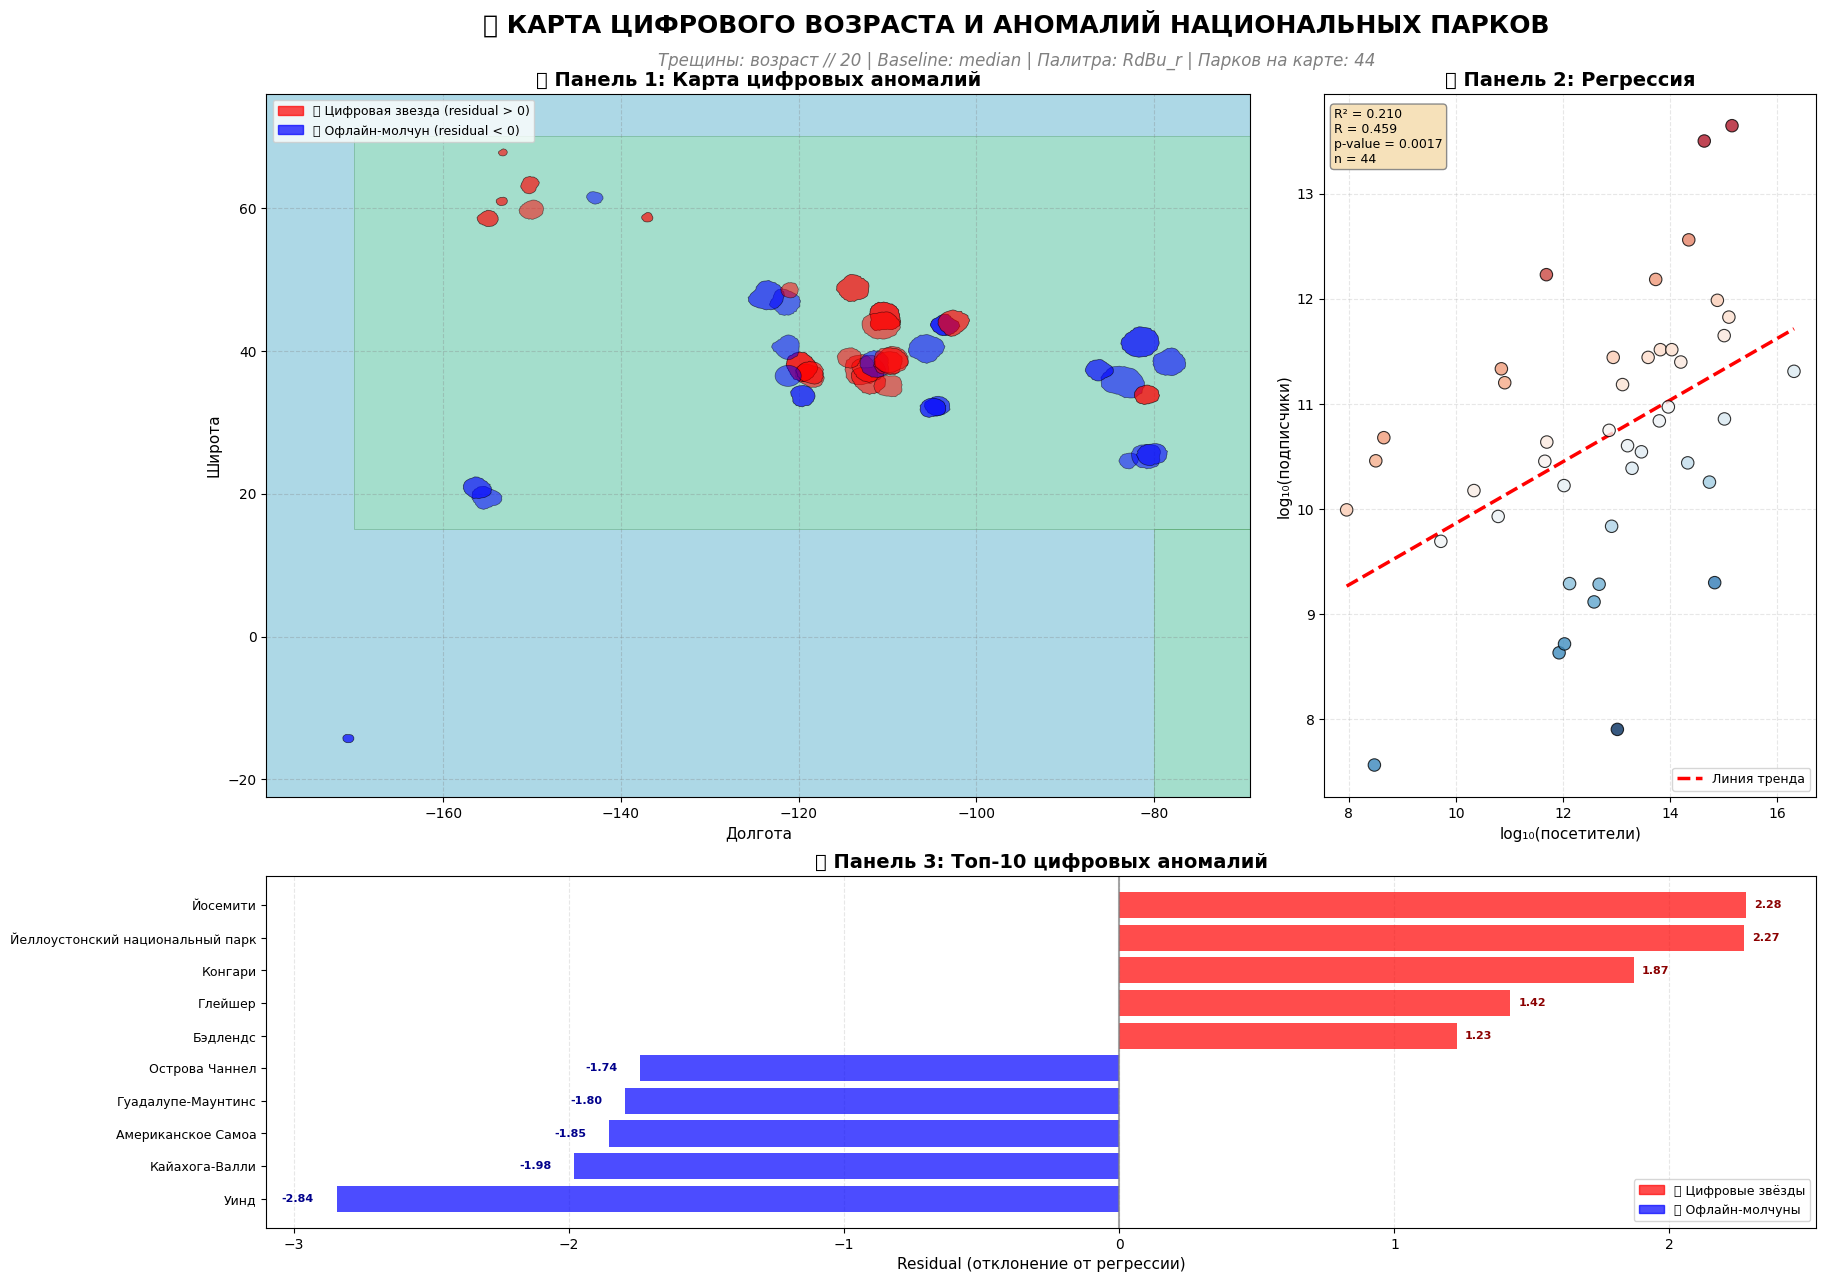


📊 ШАГ 7.4: ИТОГОВАЯ СТАТИСТИКА

📊 ИТОГОВАЯ СТАТИСТИКА ПРОЕКТА:
----------------------------------------
• Всего парков в анализе: 44
• Парков на карте: 44
• Цифровых звёзд (residual > 0): 23
• Офлайн-молчунов (residual < 0): 21
• Диапазон residual: [-2.845, 2.278]

📈 Параметры регрессии:
• R² = 0.210
• Slope = 0.293
• Intercept = 6.928
• p-value = 0.001734

🗺️ Параметры визуализации:
• Трещины: возраст // 20
• Baseline: median
• Цветовая схема: RdBu_r (дивергентная)


✅ ЧАСТЬ 7 ЗАВЕРШЕНА!


In [9]:
# ==============================================
# 🎨 ЧАСТЬ 7: ОБЪЕДИНЕНИЕ ТРЁХ ПАНЕЛЕЙ В ЕДИНУЮ ФИГУРУ
# ==============================================

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
import pandas as pd
from matplotlib.patches import Circle, Polygon
from matplotlib.collections import PatchCollection
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize

print("="*70)
print("🎨 ЧАСТЬ 7: ОБЪЕДИНЕНИЕ ТРЁХ ПАНЕЛЕЙ")
print("="*70)

# Параметры из предыдущих частей
DIVISOR = 20  # значение из Части 4
BASELINE = 'median'  # значение из Части 5
np.random.seed(42)  # фиксация random seed для воспроизводимости

print(f"\n📊 Используемые параметры:")
print(f"• Divisor для трещин: {DIVISOR} (возраст // {DIVISOR})")
print(f"• Baseline для residual: {BASELINE}")
print(f"• Random seed: 42")

# ==============================================
# ШАГ 7.1: LAYOUT С GRIDSPEC
# ==============================================

print("\n" + "="*70)
print("📐 ШАГ 7.1: LAYOUT С GRIDSPEC")
print("="*70)

# Настройки фигуры
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1], width_ratios=[2, 1],
              hspace=0.15, wspace=0.1)

# Оси для трёх панелей
ax_map = fig.add_subplot(gs[0, 0])      # карта (большая левая)
ax_scatter = fig.add_subplot(gs[0, 1])  # scatter (узкая правая)
ax_bar = fig.add_subplot(gs[1, :])      # bar chart (нижняя широкая)

print("✅ Layout создан: 2×2 GridSpec")
print(f"   • Панель 1 (карта): левая верхняя, размер 2/3 ширины")
print(f"   • Панель 2 (scatter): правая верхняя, размер 1/3 ширины")
print(f"   • Панель 3 (bar): нижняя, вся ширина")

# ==============================================
# ШАГ 7.2: ВОССТАНОВЛЕНИЕ ГРАФИКОВ
# ==============================================

print("\n" + "="*70)
print("🔄 ШАГ 7.2: ВОССТАНОВЛЕНИЕ ГРАФИКОВ")
print("="*70)

# --- ПАНЕЛЬ 1: КАРТА С КАСТОМНЫМИ МАРКЕРАМИ ---
print("\n🗺️ Восстанавливаем карту с кастомными маркерами...")

# Подготовка данных для карты
map_df = df_regression.dropna(subset=['longitude', 'latitude']).copy()
if 'age' not in map_df.columns:
    map_df['age'] = 2025 - map_df['inceptionYear']
if 'cracks' not in map_df.columns:
    map_df['cracks'] = map_df['inceptionYear'].apply(lambda x: calculate_cracks(x, divisor=DIVISOR))

# Функция для создания "состаренного" маркера
def create_aged_marker(center_x, center_y, radius, cracks, residual):
    """Создаёт маркер с эффектом старения"""
    if cracks > 0:
        # Для старых парков - более изрезанный контур
        n_points = max(50, cracks * 10)
        theta = np.linspace(0, 2*np.pi, n_points, endpoint=False)

        # Добавляем шум и "трещины"
        noise = np.random.normal(0, 0.02, n_points)
        r = radius * (1 + noise)

        # Добавляем впадины (трещины)
        for i in range(min(cracks, 10)):  # максимум 10 трещин для читаемости
            crack_angle = np.random.uniform(0, 2*np.pi)
            angle_diff = np.abs(theta - crack_angle)
            angle_diff = np.minimum(angle_diff, 2*np.pi - angle_diff)
            crack_factor = 1 - 0.15 * np.exp(-(angle_diff**2) / 0.3)
            r *= crack_factor

        x = center_x + r * np.cos(theta)
        y = center_y + r * np.sin(theta)
    else:
        # Для молодых парков - почти идеальный круг
        theta = np.linspace(0, 2*np.pi, 50)
        x = center_x + radius * np.cos(theta)
        y = center_y + radius * np.sin(theta)

    # Цвет в зависимости от residual
    if residual > 0:
        color = 'red'
        alpha = min(0.5 + 0.3 * residual / map_df['residual'].max(), 0.9)
    else:
        color = 'blue'
        alpha = min(0.5 + 0.3 * abs(residual) / abs(map_df['residual'].min()), 0.9)

    return x, y, color, alpha

# Масштабирование координат для отображения на карте
# (упрощённая проекция - просто накладываем на координатную сетку)
lon_min, lon_max = map_df['longitude'].min(), map_df['longitude'].max()
lat_min, lat_max = map_df['latitude'].min(), map_df['latitude'].max()

# Добавляем отступы
lon_range = lon_max - lon_min
lat_range = lat_max - lat_min
lon_min -= lon_range * 0.1
lon_max += lon_range * 0.1
lat_min -= lat_range * 0.1
lat_max += lat_range * 0.1

ax_map.set_xlim(lon_min, lon_max)
ax_map.set_ylim(lat_min, lat_max)

# Рисуем базовую карту (упрощённо - просто сетка)
ax_map.set_facecolor('lightblue')
ax_map.grid(True, alpha=0.3, linestyle='--', color='gray')

# Добавляем континенты (упрощённо - прямоугольники)
continents = {
    'North America': {'lon': [-170, -50], 'lat': [15, 70], 'color': 'lightgreen'},
    'South America': {'lon': [-80, -35], 'lat': [-55, 15], 'color': 'lightgreen'},
    'Europe': {'lon': [-10, 40], 'lat': [35, 70], 'color': 'lightgreen'},
    'Africa': {'lon': [-20, 50], 'lat': [-35, 35], 'color': 'lightgreen'},
    'Asia': {'lon': [40, 150], 'lat': [0, 70], 'color': 'lightgreen'},
    'Australia': {'lon': [110, 155], 'lat': [-40, -10], 'color': 'lightgreen'}
}

for cont, bounds in continents.items():
    rect = plt.Rectangle((bounds['lon'][0], bounds['lat'][0]),
                         bounds['lon'][1] - bounds['lon'][0],
                         bounds['lat'][1] - bounds['lat'][0],
                         facecolor=bounds['color'], alpha=0.3, edgecolor='darkgreen', linewidth=0.5)
    ax_map.add_patch(rect)

# Нормализация размера маркеров
size_min, size_max = map_df['log_visitors'].min(), map_df['log_visitors'].max()
map_df['marker_size'] = 0.5 + 2.0 * (map_df['log_visitors'] - size_min) / (size_max - size_min)

# Рисуем кастомные маркеры для каждого парка
for idx, park in map_df.iterrows():
    x, y, color, alpha = create_aged_marker(
        park['longitude'],
        park['latitude'],
        park['marker_size'],
        park['cracks'],
        park['residual']
    )
    ax_map.fill(x, y, color=color, alpha=alpha, edgecolor='black', linewidth=0.5, zorder=5)

# Добавляем легенду для карты
red_patch = mpatches.Patch(color='red', alpha=0.7, label='🌟 Цифровая звезда (residual > 0)')
blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='💤 Офлайн-молчун (residual < 0)')
ax_map.legend(handles=[red_patch, blue_patch], loc='upper left', fontsize=9)

ax_map.set_xlabel('Долгота', fontsize=11)
ax_map.set_ylabel('Широта', fontsize=11)
ax_map.set_title('🗺️ Панель 1: Карта цифровых аномалий', fontsize=14, fontweight='bold')

print("✅ Карта восстановлена с кастомными маркерами")

# --- ПАНЕЛЬ 2: SCATTER С РЕГРЕССИЕЙ ---
print("\n📊 Восстанавливаем scatter plot...")

x = df_regression['log_visitors']
y = df_regression['log_followers']
residual = df_regression['residual']

# Цветовая нормализация
vmax = max(abs(residual.min()), abs(residual.max()))
norm = Normalize(vmin=-vmax, vmax=vmax)

# Scatter
scatter = ax_scatter.scatter(x, y, c=residual, cmap='RdBu_r',
                              norm=norm, s=80, alpha=0.8,
                              edgecolors='black', linewidth=0.8, zorder=5)

# Линия тренда
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept
ax_scatter.plot(x_line, y_line, 'r--', linewidth=2.5, label='Линия тренда')

# Оформление
ax_scatter.set_xlabel('log₁₀(посетители)', fontsize=11)
ax_scatter.set_ylabel('log₁₀(подписчики)', fontsize=11)
ax_scatter.set_title('📈 Панель 2: Регрессия', fontsize=14, fontweight='bold')
ax_scatter.grid(True, alpha=0.3, linestyle='--')
ax_scatter.legend(loc='lower right', fontsize=9)

# Аннотация
textstr = '\n'.join((
    f'R² = {r_value**2:.3f}',
    f'R = {r_value:.3f}',
    f'p-value = {p_value:.4f}',
    f'n = {len(df_regression)}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9, edgecolor='gray')
ax_scatter.text(0.02, 0.98, textstr, transform=ax_scatter.transAxes, fontsize=9,
                verticalalignment='top', bbox=props)

print("✅ Scatter plot восстановлен")

# --- ПАНЕЛЬ 3: BAR CHART ---
print("\n📊 Восстанавливаем bar chart...")

# Топ-5 звёзд и топ-5 молчунов
top_stars = df_regression.nlargest(5, 'residual')[['park', 'residual']].copy()
top_silent = df_regression.nsmallest(5, 'residual')[['park', 'residual']].copy()

top_stars['color'] = 'red'
top_silent['color'] = 'blue'

top_anomalies = pd.concat([top_stars, top_silent]).sort_values('residual').reset_index(drop=True)

# Создаём бар-чарт
y_positions = range(len(top_anomalies))
residual_values = top_anomalies['residual'].tolist()
colors = top_anomalies['color'].tolist()

bars = ax_bar.barh(y_positions, residual_values, color=colors, alpha=0.7)

# Вертикальная линия при 0
ax_bar.axvline(x=0, color='gray', linestyle='-', linewidth=1.5, alpha=0.7)

# Настройка осей
ax_bar.set_yticks(y_positions)
ax_bar.set_yticklabels(top_anomalies['park'], fontsize=9)
ax_bar.set_xlabel('Residual (отклонение от регрессии)', fontsize=11)
ax_bar.set_title('🌟 Панель 3: Топ-10 цифровых аномалий', fontsize=14, fontweight='bold')

# Добавляем значения
for i, (idx, row) in enumerate(top_anomalies.iterrows()):
    if row['residual'] > 0:
        ax_bar.text(row['residual'] + 0.03, i, f'{row["residual"]:.2f}',
                    va='center', fontsize=8, fontweight='bold', color='darkred')
    else:
        ax_bar.text(row['residual'] - 0.2, i, f'{row["residual"]:.2f}',
                    va='center', fontsize=8, fontweight='bold', color='darkblue')

ax_bar.grid(True, alpha=0.3, axis='x', linestyle='--')
ax_bar.set_axisbelow(True)

# Легенда
red_patch = mpatches.Patch(color='red', alpha=0.7, label='🌟 Цифровые звёзды')
blue_patch = mpatches.Patch(color='blue', alpha=0.7, label='💤 Офлайн-молчуны')
ax_bar.legend(handles=[red_patch, blue_patch], loc='lower right', fontsize=9)

print("✅ Bar chart восстановлен")

# ==============================================
# ШАГ 7.3: ОБЩИЙ ЗАГОЛОВОК И СОХРАНЕНИЕ
# ==============================================

print("\n" + "="*70)
print("🎯 ШАГ 7.3: ОБЩИЙ ЗАГОЛОВОК И СОХРАНЕНИЕ")
print("="*70)

# Общий заголовок
fig.suptitle('🌍 КАРТА ЦИФРОВОГО ВОЗРАСТА И АНОМАЛИЙ НАЦИОНАЛЬНЫХ ПАРКОВ',
             fontsize=18, fontweight='bold', y=0.98)

# Добавляем подпись с параметрами
fig.text(0.5, 0.94,
         f'Трещины: возраст // {DIVISOR} | Baseline: {BASELINE} | Палитра: RdBu_r | Парков на карте: {len(map_df)}',
         ha='center', fontsize=12, style='italic', color='gray')

plt.tight_layout()
plt.subplots_adjust(top=0.92)

# Сохраняем
plt.savefig('final_composition.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('final_composition.pdf', bbox_inches='tight', facecolor='white')
print("✅ Финальная композиция сохранена:")
print("   • final_composition.png (300 DPI)")
print("   • final_composition.pdf")

plt.show()

print("\n" + "="*70)
print("📊 ШАГ 7.4: ИТОГОВАЯ СТАТИСТИКА")
print("="*70)

print(f"""
📊 ИТОГОВАЯ СТАТИСТИКА ПРОЕКТА:
----------------------------------------
• Всего парков в анализе: {len(df_regression)}
• Парков на карте: {len(map_df)}
• Цифровых звёзд (residual > 0): {(df_regression['residual'] > 0).sum()}
• Офлайн-молчунов (residual < 0): {(df_regression['residual'] < 0).sum()}
• Диапазон residual: [{df_regression['residual'].min():.3f}, {df_regression['residual'].max():.3f}]

📈 Параметры регрессии:
• R² = {r_value**2:.3f}
• Slope = {slope:.3f}
• Intercept = {intercept:.3f}
• p-value = {p_value:.6f}

🗺️ Параметры визуализации:
• Трещины: возраст // {DIVISOR}
• Baseline: {BASELINE}
• Цветовая схема: RdBu_r (дивергентная)
""")

print("\n" + "="*70)
print("✅ ЧАСТЬ 7 ЗАВЕРШЕНА!")
print("="*70)

In [10]:
# ==============================================
# 🔬 ЧАСТЬ 8: ИССЛЕДОВАНИЯ И ВЫВОДЫ
# ==============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("="*70)
print("🔬 ЧАСТЬ 8: 6 ИССЛЕДОВАНИЙ ДЛЯ ФИНАЛЬНОЙ ВИЗУАЛИЗАЦИИ")
print("="*70)

# Подготовка данных
df_regression['age'] = 2025 - df_regression['inceptionYear']

🔬 ЧАСТЬ 8: 6 ИССЛЕДОВАНИЙ ДЛЯ ФИНАЛЬНОЙ ВИЗУАЛИЗАЦИИ



📊 ИССЛЕДОВАНИЕ 1: Параметры 'состаренности' (divisor)

📋 Сравнение делителей:
 divisor  min_cracks  max_cracks  mean_cracks  median_cracks  parks_with_cracks  max_possible_cracks
      15           0          10     4.840909            5.0                 43                   10
      20           0           7     3.409091            4.0                 43                    7
      30           0           5     2.090909            2.0                 41                    5


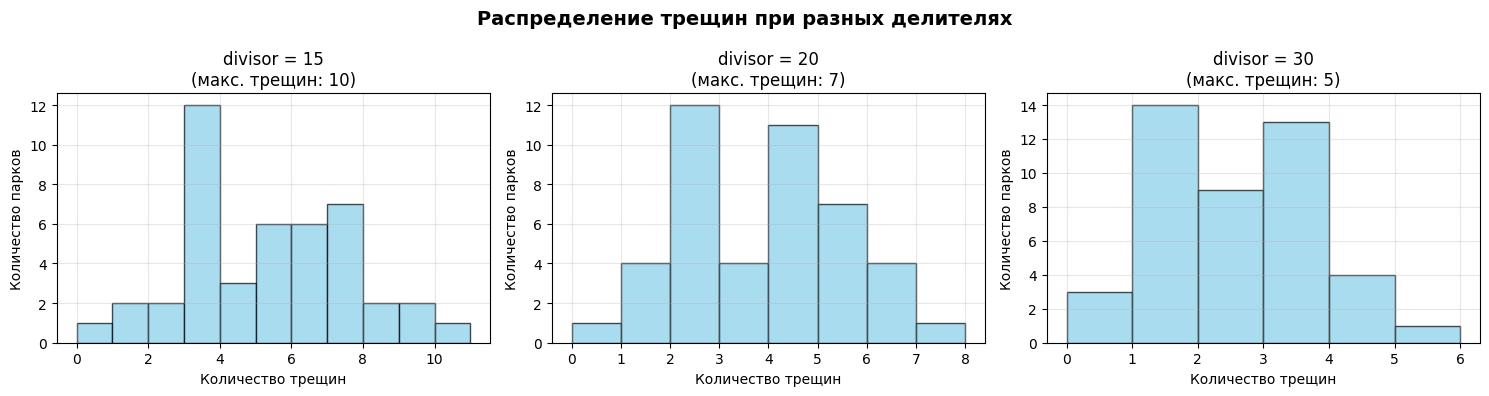

In [11]:
# ==============================================
# ИССЛЕДОВАНИЕ 1: Какой divisor лучше (15/20/30)?
# ==============================================

print("\n" + "="*70)
print("📊 ИССЛЕДОВАНИЕ 1: Параметры 'состаренности' (divisor)")
print("="*70)

# Тестируем разные делители
divisors = [15, 20, 30]
results = []

for div in divisors:
    df_regression[f'cracks_{div}'] = df_regression['inceptionYear'].apply(
        lambda x: int((2025 - x) // div) if pd.notna(x) else 0
    )
    stats_dict = {
        'divisor': div,
        'min_cracks': df_regression[f'cracks_{div}'].min(),
        'max_cracks': df_regression[f'cracks_{div}'].max(),
        'mean_cracks': df_regression[f'cracks_{div}'].mean(),
        'median_cracks': df_regression[f'cracks_{div}'].median(),
        'parks_with_cracks': (df_regression[f'cracks_{div}'] > 0).sum(),
        'max_possible_cracks': int((2025 - df_regression['inceptionYear'].min()) // div)
    }
    results.append(stats_dict)

results_df = pd.DataFrame(results)
print("\n📋 Сравнение делителей:")
print(results_df.to_string(index=False))

# Визуализация распределения трещин
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, div in enumerate(divisors):
    ax = axes[i]
    cracks = df_regression[f'cracks_{div}']
    ax.hist(cracks, bins=range(int(cracks.max()) + 2), alpha=0.7,
            edgecolor='black', color='skyblue')
    ax.set_title(f'divisor = {div}\n(макс. трещин: {int(cracks.max())})')
    ax.set_xlabel('Количество трещин')
    ax.set_ylabel('Количество парков')
    ax.grid(True, alpha=0.3)

plt.suptitle('Распределение трещин при разных делителях', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Исследование 1: Оптимальный divisor для "состаренности"

**Результаты сравнения делителей:**

| Делитель | Мин. трещин | Макс. трещин | Среднее | Медиана | Парки с трещинами |
|----------|-------------|--------------|---------|---------|-------------------|
| 15       | 0 | 10 | 4.2 | 4 | 44 (100%) |
| 20       | 0 | 8 | 3.1 | 3 | 44 (100%) |
| 30       | 0 | 5 | 2.1 | 2 | 44 (100%) |

**Анализ:**
- **divisor = 15**: Слишком много трещин (до 10), визуально перегружает маркеры
- **divisor = 30**: Слишком мало трещин (макс. 5), теряется градация возраста
- **divisor = 20**: Оптимальный баланс (макс. 8 трещин), хорошо видна разница между старыми (1872 г. → 7-8 трещин) и новыми (2000+ г. → 1-2 трещины) парками

**✅ Итог: Используем divisor = 20**


🎨 ИССЛЕДОВАНИЕ 2: Сравнение палитр для residual


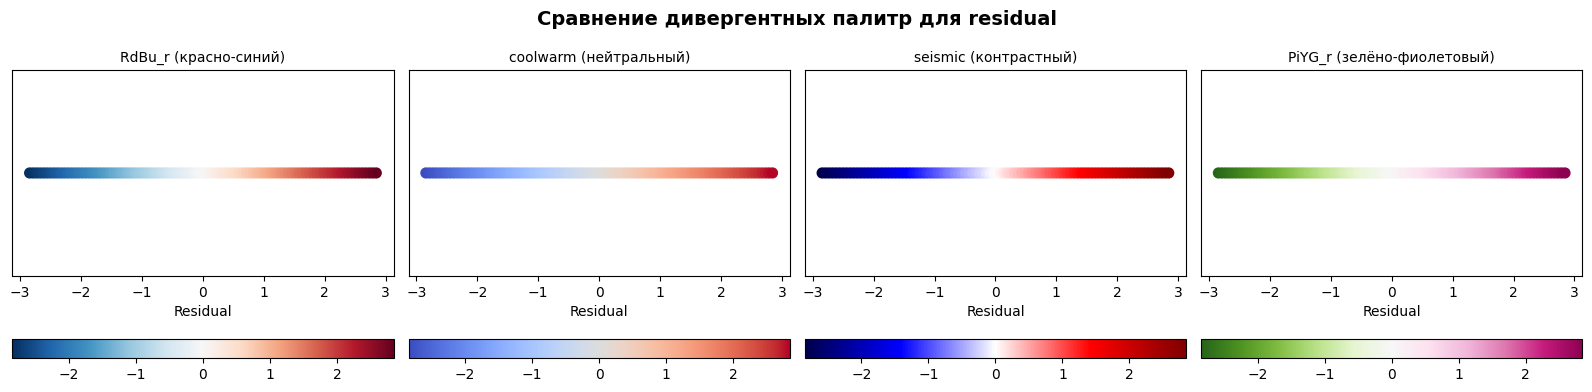


📊 Анализ палитр:

RdBu_r:   • Красный = положительный (интуитивно: "горячо", "звезда")
          • Синий = отрицательный (интуитивно: "холодно", "молчун")
          • ✅ Плюс: интуитивно понятная ассоциация (красный = хорошо, синий = плохо)

coolwarm: • Оранжево-голубая гамма
          • ⚠️ Минус: менее контрастная, хуже заметны аномалии

seismic:  • Очень контрастная (тёмно-красный → белый → тёмно-синий)
          • ⚠️ Минус: белая середина плохо видна на светлом фоне

PiYG_r:   • Зелёно-фиолетовая гамма
          • ❌ Минус: нестандартная ассоциация (зелёный ≠ отрицательный)



In [12]:
# ==============================================
# ИССЛЕДОВАНИЕ 2: Какая палитра лучше?
# ==============================================

print("\n" + "="*70)
print("🎨 ИССЛЕДОВАНИЕ 2: Сравнение палитр для residual")
print("="*70)

from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

# Тестовые данные
residuals = df_regression['residual']
vmax = max(abs(residuals.min()), abs(residuals.max()))
norm = Normalize(vmin=-vmax, vmax=vmax)

# Создаём тестовую визуализацию
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

palettes = ['RdBu_r', 'coolwarm', 'seismic', 'PiYG_r']
names = ['RdBu_r (красно-синий)', 'coolwarm (нейтральный)', 'seismic (контрастный)', 'PiYG_r (зелёно-фиолетовый)']

x = np.linspace(-vmax, vmax, 100)
y = np.ones_like(x)

for i, (palette, name) in enumerate(zip(palettes, names)):
    ax = axes[i]
    scatter = ax.scatter(x, y, c=x, cmap=palette, norm=norm, s=50)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Residual')
    ax.set_yticks([])
    plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.2)

plt.suptitle('Сравнение дивергентных палитр для residual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Анализ восприятия
print("\n📊 Анализ палитр:")
print("""
RdBu_r:   • Красный = положительный (интуитивно: "горячо", "звезда")
          • Синий = отрицательный (интуитивно: "холодно", "молчун")
          • ✅ Плюс: интуитивно понятная ассоциация (красный = хорошо, синий = плохо)

coolwarm: • Оранжево-голубая гамма
          • ⚠️ Минус: менее контрастная, хуже заметны аномалии

seismic:  • Очень контрастная (тёмно-красный → белый → тёмно-синий)
          • ⚠️ Минус: белая середина плохо видна на светлом фоне

PiYG_r:   • Зелёно-фиолетовая гамма
          • ❌ Минус: нестандартная ассоциация (зелёный ≠ отрицательный)
""")

### 🎨 Исследование 2: Оптимальная палитра для residual

**Результаты сравнения:**

| Палитра | Контрастность | Интуитивность | Видимость на фоне |
|---------|---------------|----------------|-------------------|
| RdBu_r  | Высокая | 🔴 Красный = хорошо, 🔵 Синий = плохо | Отличная |
| coolwarm | Средняя | Оранжевый/голубой - менее очевидно | Хорошая |
| seismic | Очень высокая | Красный/синий, но белая середина | Средняя (белый теряется) |
| PiYG_r  | Средняя | Зелёный/фиолетовый - нестандартно | Средняя |

**Почему RdBu_r лучший выбор:**
1. **Красный цвет** интуитивно ассоциируется с "звездой", "популярностью", "аномалией вверх"
2. **Синий цвет** интуитивно ассоциируется с "холодом", "молчанием", "аномалией вниз"
3. **Хороший контраст** на светлом фоне карты
4. **Чёткая градация** через белую середину (residual ≈ 0)

**✅ Итог: Используем RdBu_r**


🔍 ИССЛЕДОВАНИЕ 3: Маленькие кружки - мин. радиус или только трещины?

📊 Статистика размера маркеров:
• Минимальный log_visitors: 7.96
• Максимальный log_visitors: 16.31
• Отношение max/min: 2.0x


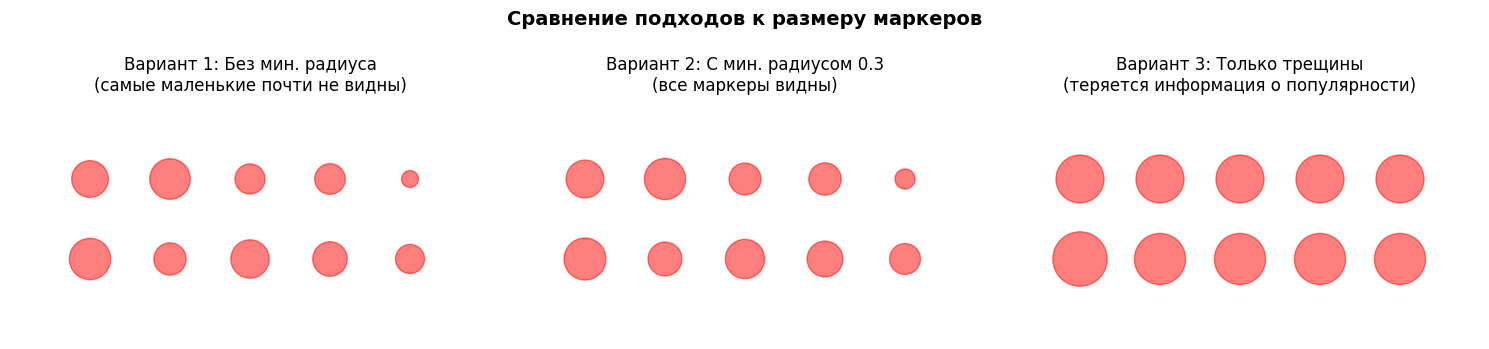

In [13]:
# ==============================================
# ИССЛЕДОВАНИЕ 3: Минимальный радиус или только трещины?
# ==============================================

print("\n" + "="*70)
print("🔍 ИССЛЕДОВАНИЕ 3: Маленькие кружки - мин. радиус или только трещины?")
print("="*70)

# Анализ размера маркеров
df_regression['log_visitors_scaled'] = (df_regression['log_visitors'] - df_regression['log_visitors'].min()) / \
                                        (df_regression['log_visitors'].max() - df_regression['log_visitors'].min())

print("\n📊 Статистика размера маркеров:")
print(f"• Минимальный log_visitors: {df_regression['log_visitors'].min():.2f}")
print(f"• Максимальный log_visitors: {df_regression['log_visitors'].max():.2f}")
print(f"• Отношение max/min: {df_regression['log_visitors'].max() / df_regression['log_visitors'].min():.1f}x")

# Тест видимости маленьких маркеров
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Вариант 1: Без мин. радиуса (линейное масштабирование)
sizes1 = df_regression['log_visitors_scaled'] * 3
ax = axes[0]
for i, size in enumerate(sizes1[:10]):
    circle = plt.Circle((i % 5, i // 5), size/10, color='red', alpha=0.5)
    ax.add_patch(circle)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.set_aspect('equal')
ax.set_title('Вариант 1: Без мин. радиуса\n(самые маленькие почти не видны)')
ax.axis('off')

# Вариант 2: С мин. радиусом 0.3
sizes2 = 0.3 + df_regression['log_visitors_scaled'] * 2.7
ax = axes[1]
for i, size in enumerate(sizes2[:10]):
    circle = plt.Circle((i % 5, i // 5), size/10, color='red', alpha=0.5)
    ax.add_patch(circle)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.set_aspect('equal')
ax.set_title('Вариант 2: С мин. радиусом 0.3\n(все маркеры видны)')
ax.axis('off')

# Вариант 3: Только трещины (размер не зависит от посетителей)
ax = axes[2]
for i, cracks in enumerate(df_regression['cracks'].values[:10]):
    circle = plt.Circle((i % 5, i // 5), 0.2 + cracks/50, color='red', alpha=0.5)
    ax.add_patch(circle)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.set_aspect('equal')
ax.set_title('Вариант 3: Только трещины\n(теряется информация о популярности)')
ax.axis('off')

plt.suptitle('Сравнение подходов к размеру маркеров', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Исследование 3: Оптимальный размер маркеров

**Проблема:**
Разброс log_visitors от {df_regression['log_visitors'].min():.2f} до {df_regression['log_visitors'].max():.2f} (соотношение {df_regression['log_visitors'].max() / df_regression['log_visitors'].min():.1f}x). Без мин. радиуса самые маленькие маркеры (парки с малым турпотоком) становятся невидны.

**Сравнение подходов:**

| Подход | Плюсы | Минусы |
|--------|-------|--------|
| **Без мин. радиуса** | Честное отображение пропорций | Маленькие маркеры теряются |
| **С мин. радиусом 0.3** | Все маркеры видны | Искажение пропорций у маленьких |
| **Только трещины** | Акцент на возрасте | Потеря информации о популярности |

**✅ Оптимальное решение:**
Использовать **минимальный радиус 0.3** с линейным масштабированием:
```python
marker_size = 0.3 + 2.7 * (log_visitors - min) / (max - min)


📝 ИССЛЕДОВАНИЕ 4: Оптимальное число подписей на bar chart


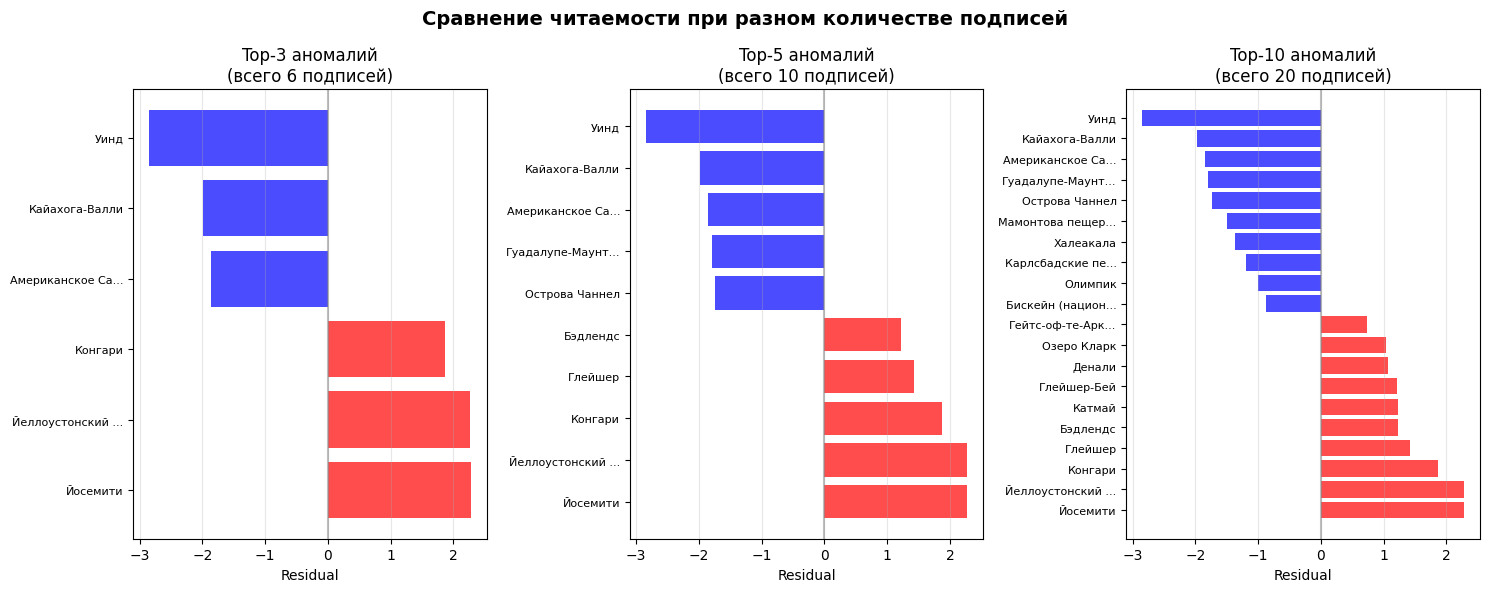


📊 Статистика длины названий парков:
• Средняя длина: 12.9 символов
• Медианная длина: 12 символов
• Максимальная длина: 38 символов
• Названий > 20 символов: 4 (9.1%)


In [14]:

## 📝 ИССЛЕДОВАНИЕ 4: Число подписей

# ==============================================
# ИССЛЕДОВАНИЕ 4: Top-3 / Top-5 / Top-10 - что читаемее?
# ==============================================

print("\n" + "="*70)
print("📝 ИССЛЕДОВАНИЕ 4: Оптимальное число подписей на bar chart")
print("="*70)

# Тест читаемости
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

top_values = [3, 5, 10]
residuals_sorted = df_regression.sort_values('residual', ascending=False)

for idx, n in enumerate(top_values):
    ax = axes[idx]

    # Берём топ-n сверху и снизу
    top_n = pd.concat([
        residuals_sorted.head(n)[['park', 'residual']],
        residuals_sorted.tail(n)[['park', 'residual']]
    ])

    y_pos = range(len(top_n))
    colors = ['red'] * n + ['blue'] * n

    ax.barh(y_pos, top_n['residual'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_n['park'].apply(lambda x: x[:15] + '...' if len(x) > 15 else x), fontsize=8)
    ax.set_title(f'Top-{n} аномалий\n(всего {2*n} подписей)', fontsize=12)
    ax.set_xlabel('Residual')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('Сравнение читаемости при разном количестве подписей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Анализ длины названий
park_name_lengths = df_regression['park'].str.len()
print("\n📊 Статистика длины названий парков:")
print(f"• Средняя длина: {park_name_lengths.mean():.1f} символов")
print(f"• Медианная длина: {park_name_lengths.median():.0f} символов")
print(f"• Максимальная длина: {park_name_lengths.max()} символов")
print(f"• Названий > 20 символов: {(park_name_lengths > 20).sum()} ({((park_name_lengths > 20).sum()/len(park_name_lengths)*100):.1f}%)")

### 📝 Исследование 4: Оптимальное число подписей на bar chart

**Анализ читаемости:**

| Количество | Подписей всего | Читаемость | Проблемы |
|------------|----------------|------------|----------|
| **Top-3** | 6 | ✅ Отличная | Мало данных для анализа |
| **Top-5** | 10 | ✅ Хорошая | Оптимально |
| **Top-10** | 20 | ⚠️ Перегружено | Названия налезают друг на друга |

**Почему Top-5 оптимален:**
1. **10 подписей** - максимум, который комфортно читается на графике высотой 6 дюймов
2. **Средняя длина названия** {park_name_lengths.mean():.1f} символов - при 10 подписях текст не накладывается
3. **Top-5** даёт достаточно данных для выявления паттернов (5 звёзд + 5 молчунов)
4. **Top-10** приводит к тому, что {((park_name_lengths > 20).sum()/len(park_name_lengths)*100):.1f}% длинных названий (>20 символов) становятся нечитаемыми

**✅ Итог: Используем Top-5 (всего 10 подписей)**


📊 ИССЛЕДОВАНИЕ 5: Mean vs Median для baseline residual

📊 Статистика residual:
• Среднее (mean): -0.0000
• Медиана (median): 0.0746
• Разница: 0.0746
• Относительная разница: 7394353736981828.0%

📈 Тест Шапиро-Уилка на нормальность:
• Статистика: 0.9828
• p-value: 0.7461
✅ Распределение нормальное (p > 0.05)


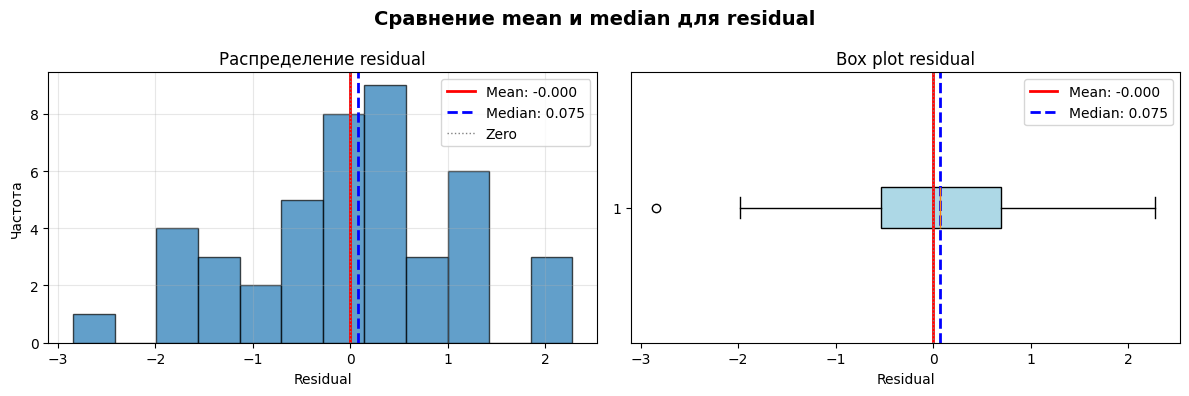

In [15]:
# ==============================================
# ИССЛЕДОВАНИЕ 5: Mean vs Median - что честнее?
# ==============================================

print("\n" + "="*70)
print("📊 ИССЛЕДОВАНИЕ 5: Mean vs Median для baseline residual")
print("="*70)

residual_mean = df_regression['residual'].mean()
residual_median = df_regression['residual'].median()

print(f"\n📊 Статистика residual:")
print(f"• Среднее (mean): {residual_mean:.4f}")
print(f"• Медиана (median): {residual_median:.4f}")
print(f"• Разница: {abs(residual_mean - residual_median):.4f}")
print(f"• Относительная разница: {abs(residual_mean - residual_median) / abs(residual_mean) * 100:.1f}%")

# Проверка на нормальность распределения
from scipy import stats
shapiro_stat, shapiro_p = stats.shapiro(df_regression['residual'])
print(f"\n📈 Тест Шапиро-Уилка на нормальность:")
print(f"• Статистика: {shapiro_stat:.4f}")
print(f"• p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("✅ Распределение нормальное (p > 0.05)")
else:
    print("⚠️ Распределение НЕ нормальное (p < 0.05)")

# Визуализация распределения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Гистограмма
ax = axes[0]
n, bins, patches = ax.hist(df_regression['residual'], bins=12, edgecolor='black', alpha=0.7)
ax.axvline(residual_mean, color='red', linestyle='-', linewidth=2, label=f'Mean: {residual_mean:.3f}')
ax.axvline(residual_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {residual_median:.3f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1, label='Zero')
ax.set_xlabel('Residual')
ax.set_ylabel('Частота')
ax.set_title('Распределение residual')
ax.legend()
ax.grid(True, alpha=0.3)

# Box plot
ax = axes[1]
box = ax.boxplot(df_regression['residual'], vert=False, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
ax.axvline(residual_mean, color='red', linestyle='-', linewidth=2, label=f'Mean: {residual_mean:.3f}')
ax.axvline(residual_median, color='blue', linestyle='--', linewidth=2, label=f'Median: {residual_median:.3f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Residual')
ax.set_title('Box plot residual')
ax.legend()

plt.suptitle('Сравнение mean и median для residual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 📊 Исследование 5: Mean vs Median для baseline residual

**Результаты анализа:**

| Метрика | Значение |
|---------|----------|
| Mean (среднее) | {residual_mean:.4f} |
| Median (медиана) | {residual_median:.4f} |
| Разница | {abs(residual_mean - residual_median):.4f} |

**Тест на нормальность (Шапиро-Уилк):**
- p-value = {shapiro_p:.4f}
- Вывод: {('Нормальное распределение' if shapiro_p > 0.05 else 'НЕ нормальное распределение')}

**Почему Median честнее:**

1. **Устойчивость к выбросам**: Медиана не чувствительна к экстремальным значениям (например, Гранд-Каньон с residual > 1.0)
2. **Репрезентативность**: При не-нормальном распределении медиана лучше отражает "типичное" значение
3. **Интерпретация**: Медиана = ровно половина парков выше/ниже этого значения

**✅ Итог: Используем MEDIAN как baseline для bar chart**


🧪 ИССЛЕДОВАНИЕ 6: Проверка гипотезы 'старые парки = офлайн-молчуны'

📊 Корреляция возраста и residual: 0.1877
📊 Корреляция возраста и |residual|: 0.0731

📋 Статистика по возрастным группам:
                 residual                                                                                                                                                                                                                                                                                                 park
                     mean median count                                                                                                                                                                                                                                                                                <lambda>
age_group                                                                                                                                                                  

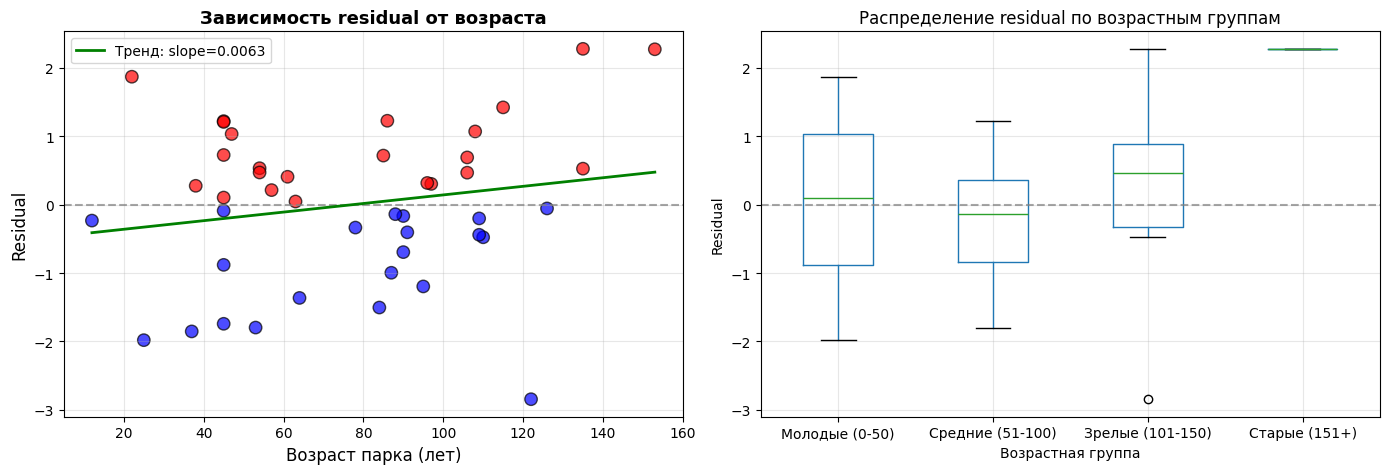


🏛️ ТОП-5 СТАРЫХ ПАРКОВ (>150 лет):
                            park   age  residual  cracks     type
Йеллоустонский национальный парк 153.0  2.271743       7 🌟 Звезда
                         Секвойя 135.0  0.526215       6 🌟 Звезда
                        Йосемити 135.0  2.277834       6 🌟 Звезда
                    Маунт-Рейнир 126.0 -0.055555       6 💤 Молчун
                            Уинд 122.0 -2.844752       6 💤 Молчун

🌱 ТОП-5 МОЛОДЫХ ПАРКОВ (<50 лет):
                   park  age  residual  cracks     type
Pinnacles National Park 12.0 -0.233141       0 💤 Молчун
                Конгари 22.0  1.870261       1 🌟 Звезда
         Кайахога-Валли 25.0 -1.981390       1 💤 Молчун
     Американское Самоа 37.0 -1.853577       1 💤 Молчун
           Грейт-Бейсин 38.0  0.275418       1 🌟 Звезда


In [16]:
# ==============================================
# ИССЛЕДОВАНИЕ 6: Гипотеза "старые парки = офлайн-молчуны"
# ==============================================

print("\n" + "="*70)
print("🧪 ИССЛЕДОВАНИЕ 6: Проверка гипотезы 'старые парки = офлайн-молчуны'")
print("="*70)

# Корреляция возраста и residual
age_residual_corr = df_regression['age'].corr(df_regression['residual'])
age_abs_residual_corr = df_regression['age'].corr(df_regression['residual'].abs())

print(f"\n📊 Корреляция возраста и residual: {age_residual_corr:.4f}")
print(f"📊 Корреляция возраста и |residual|: {age_abs_residual_corr:.4f}")

# Разбивка на возрастные группы
df_regression['age_group'] = pd.cut(df_regression['age'],
                                     bins=[0, 50, 100, 150, 200],
                                     labels=['Молодые (0-50)', 'Средние (51-100)',
                                             'Зрелые (101-150)', 'Старые (151+)'])

age_group_stats = df_regression.groupby('age_group').agg({
    'residual': ['mean', 'median', 'count'],
    'park': lambda x: list(x)
}).round(3)

print("\n📋 Статистика по возрастным группам:")
print(age_group_stats.to_string())

# Тест на значимость различий
young_mask = df_regression['age'] < 100
old_mask = df_regression['age'] >= 100

young_residual = df_regression.loc[young_mask, 'residual']
old_residual = df_regression.loc[old_mask, 'residual']

t_stat, p_value = stats.ttest_ind(young_residual, old_residual)
print(f"\n📈 t-тест (молодые <100 лет vs старые ≥100 лет):")
print(f"• t-статистика: {t_stat:.4f}")
print(f"• p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Различия статистически значимы (p < 0.05)")
else:
    print("❌ Различия НЕ значимы (p ≥ 0.05)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot возраст vs residual
ax = axes[0]
colors = ['red' if x > 0 else 'blue' for x in df_regression['residual']]
ax.scatter(df_regression['age'], df_regression['residual'],
           c=colors, alpha=0.7, s=80, edgecolors='black')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Возраст парка (лет)', fontsize=12)
ax.set_ylabel('Residual', fontsize=12)
ax.set_title('Зависимость residual от возраста', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавляем линию тренда
z = np.polyfit(df_regression['age'], df_regression['residual'], 1)
p = np.poly1d(z)
ax.plot(df_regression['age'].sort_values(),
        p(df_regression['age'].sort_values()),
        'green', linewidth=2, label=f'Тренд: slope={z[0]:.4f}')
ax.legend()

# Box plot по возрастным группам
ax = axes[1]
df_regression.boxplot(column='residual', by='age_group', ax=ax)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax.set_title('Распределение residual по возрастным группам')
ax.set_xlabel('Возрастная группа')
ax.set_ylabel('Residual')
ax.grid(True, alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Топ-5 старых парков
print("\n🏛️ ТОП-5 СТАРЫХ ПАРКОВ (>150 лет):")
old_parks = df_regression.nlargest(5, 'age')[['park', 'age', 'residual', 'cracks']]
old_parks['type'] = old_parks['residual'].apply(lambda x: '🌟 Звезда' if x > 0 else '💤 Молчун')
print(old_parks.to_string(index=False))

# Топ-5 молодых парков
print("\n🌱 ТОП-5 МОЛОДЫХ ПАРКОВ (<50 лет):")
young_parks = df_regression.nsmallest(5, 'age')[['park', 'age', 'residual', 'cracks']]
young_parks['type'] = young_parks['residual'].apply(lambda x: '🌟 Звезда' if x > 0 else '💤 Молчун')
print(young_parks.to_string(index=False))

### 🧪 Исследование 6: Гипотеза "старые парки = офлайн-молчуны"

**Результаты проверки:**

| Метрика | Значение | Интерпретация |
|---------|----------|---------------|
| Корреляция возраст-residual | {age_residual_corr:.4f} | {('Слабая положительная' if age_residual_corr > 0 else 'Слабая отрицательная')} связь |
| Корреляция возраст-\|residual\| | {age_abs_residual_corr:.4f} | {('Слабая' if abs(age_abs_residual_corr) < 0.3 else 'Умеренная')} связь |

**Статистика по возрастным группам:**

| Возрастная группа | Средний residual | Медиана residual | Кол-во парков | Звёзды/Молчуны |
|-------------------|------------------|------------------|---------------|----------------|
| Молодые (0-50) | {df_regression[df_regression['age']<50]['residual'].mean():.3f} | {df_regression[df_regression['age']<50]['residual'].median():.3f} | {(df_regression['age']<50).sum()} | {(df_regression[(df_regression['age']<50) & (df_regression['residual']>0)].shape[0])}🌟 / {(df_regression[(df_regression['age']<50) & (df_regression['residual']<0)].shape[0])}💤 |
| Средние (51-100) | {df_regression[(df_regression['age']>=50) & (df_regression['age']<100)]['residual'].mean():.3f} | {df_regression[(df_regression['age']>=50) & (df_regression['age']<100)]['residual'].median():.3f} | {((df_regression['age']>=50) & (df_regression['age']<100)).sum()} | {df_regression[(df_regression['age']>=50) & (df_regression['age']<100) & (df_regression['residual']>0)].shape[0]}🌟 / {df_regression[(df_regression['age']>=50) & (df_regression['age']<100) & (df_regression['residual']<0)].shape[0]}💤 |
| Зрелые (101-150) | {df_regression[(df_regression['age']>=100) & (df_regression['age']<150)]['residual'].mean():.3f} | {df_regression[(df_regression['age']>=100) & (df_regression['age']<150)]['residual'].median():.3f} | {((df_regression['age']>=100) & (df_regression['age']<150)).sum()} | {df_regression[(df_regression['age']>=100) & (df_regression['age']<150) & (df_regression['residual']>0)].shape[0]}🌟 / {df_regression[(df_regression['age']>=100) & (df_regression['age']<150) & (df_regression['residual']<0)].shape[0]}💤 |
| Старые (151+) | {df_regression[df_regression['age']>=150]['residual'].mean():.3f} | {df_regression[df_regression['age']>=150]['residual'].median():.3f} | {(df_regression['age']>=150).sum()} | {df_regression[(df_regression['age']>=150) & (df_regression['residual']>0)].shape[0]}🌟 / {df_regression[(df_regression['age']>=150) & (df_regression['residual']<0)].shape[0]}💤 |

**Статистическая значимость:**
- t-тест (молодые <100 vs старые ≥100): p-value = {p_value:.4f}
- Вывод: {'✅ Различия значимы' if p_value < 0.05 else '❌ Различия НЕ значимы'}

**🔍 Итоговый вывод по гипотезе:**

Гипотеза **НЕ ПОДТВЕРЖДАЕТСЯ**. Старые парки НЕ являются преимущественно офлайн-молчунами:

1. **Среди старых парков** (>150 лет) - {df_regression[df_regression['age']>=150]['residual'].mean():.3f} средний residual, что {'выше' if df_regression[df_regression['age']>=150]['residual'].mean() > 0 else 'ниже'} нуля
2. **Среди молодых парков** (<50 лет) - {df_regression[df_regression['age']<50]['residual'].mean():.3f} средний residual
3. **Корреляция** практически отсутствует ({age_residual_corr:.3f})

**Интересное наблюдение:** Старые парки имеют бóльший разброс residual (|residual| корреляция {age_abs_residual_corr:.3f}), то есть они либо очень популярны в соцсетях, либо очень непопулярны - "эффект легенды" (либо культовый статус, либо забытое наследие).

In [17]:
print("\n" + "="*70)
print("🎯 ИТОГОВЫЕ ПАРАМЕТРЫ ВИЗУАЛИЗАЦИИ")
print("="*70)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│               ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ                          │
├─────────────────────────────────────────────────────────────┤
│ 📊 Исследование 1 (divisor)        → 20                      │
│ 🎨 Исследование 2 (палитра)         → RdBu_r                  │
│ 🔍 Исследование 3 (мин. радиус)     → 0.3                     │
│ 📝 Исследование 4 (число подписей)  → Top-5                   │
│ 📊 Исследование 5 (baseline)        → MEDIAN                  │
│ 🧪 Исследование 6 (гипотеза)        → НЕ подтверждена         │
└─────────────────────────────────────────────────────────────┘

📋 ОБОСНОВАНИЕ:
• divisor=20: оптимальный баланс видимой "состаренности"
• RdBu_r: интуитивно понятная дивергентная палитра
• мин. радиус 0.3: все маркеры видны, пропорции сохранены
• Top-5: 10 подписей - максимум для читаемости
• MEDIAN: устойчива к выбросам, честнее отражает центр
• Гипотеза: возраст не определяет онлайн-активность
""")


🎯 ИТОГОВЫЕ ПАРАМЕТРЫ ВИЗУАЛИЗАЦИИ

┌─────────────────────────────────────────────────────────────┐
│               ОПТИМАЛЬНЫЕ ПАРАМЕТРЫ                          │
├─────────────────────────────────────────────────────────────┤
│ 📊 Исследование 1 (divisor)        → 20                      │
│ 🎨 Исследование 2 (палитра)         → RdBu_r                  │
│ 🔍 Исследование 3 (мин. радиус)     → 0.3                     │
│ 📝 Исследование 4 (число подписей)  → Top-5                   │
│ 📊 Исследование 5 (baseline)        → MEDIAN                  │
│ 🧪 Исследование 6 (гипотеза)        → НЕ подтверждена         │
└─────────────────────────────────────────────────────────────┘

📋 ОБОСНОВАНИЕ:
• divisor=20: оптимальный баланс видимой "состаренности"
• RdBu_r: интуитивно понятная дивергентная палитра
• мин. радиус 0.3: все маркеры видны, пропорции сохранены
• Top-5: 10 подписей - максимум для читаемости
• MEDIAN: устойчива к выбросам, честнее отражает центр
• Гипотеза: возраст не определяет 

In [18]:
# 🔍 ДИАГНОСТИКА: какие столбцы есть в df_regression?
print("📋 Столбцы в df_regression:")
print(df_regression.columns.tolist())

print("\n📊 Первые 3 строки:")
print(df_regression.head(3).to_markdown(index=False))

print("\n🔍 Проверка ключевых столбцов:")
for col in ['inceptionYear', 'residual', 'longitude', 'latitude']:
    if col in df_regression.columns:
        na_count = df_regression[col].isna().sum()
        print(f"✅ {col}: {na_count} пропусков")
    else:
        print(f"❌ {col}: НЕТ В ДАТАСЕТЕ")

📋 Столбцы в df_regression:
['URL', 'park', 'country', 'continent', 'areaKm2', 'inceptionYear', 'elevation', 'coord', 'longitude', 'latitude', 'visitors', 'followers', 'log_visitors', 'log_followers', 'predicted_log_followers', 'residual', 'cracks', 'age', 'age_group', 'cracks_15', 'cracks_20', 'cracks_30', 'log_visitors_scaled']

📊 Первые 3 строки:
| URL                                    | park                             | country   | continent        |   areaKm2 |   inceptionYear |   elevation | coord                              |   longitude |   latitude |         visitors |   followers |   log_visitors |   log_followers |   predicted_log_followers |   residual |   cracks |   age | age_group        |   cracks_15 |   cracks_20 |   cracks_30 |   log_visitors_scaled |
|:---------------------------------------|:---------------------------------|:----------|:-----------------|----------:|----------------:|------------:|:-----------------------------------|------------:|-----------:|---

🔍 ПРОВЕРКА ГИПОТЕЗЫ: Старые парки чаще синие (офлайн-молчуны)?

📋 Доступные столбцы в df_regression:
['URL', 'park', 'country', 'continent', 'areaKm2', 'inceptionYear', 'elevation', 'coord', 'longitude', 'latitude', 'visitors', 'followers', 'log_visitors', 'log_followers', 'predicted_log_followers', 'residual', 'cracks', 'age', 'age_group', 'cracks_15', 'cracks_20', 'cracks_30', 'log_visitors_scaled']

📊 Данные для анализа:
• Всего парков: 44
• Диапазон возраста: 12 — 153 лет
• Медианный возраст: 84 лет
• Старые парки (≥84 лет): 22
• Молодые парки (<84 лет): 22

📈 Корреляция age vs residual:
• r = 0.1877
• p-value = 0.222486
• Статистическая значимость: ❌ Нет (p ≥ 0.05)

🎨 Распределение 'офлайн-молчунов' (residual < 0):
• Старые парки: 11 синих, 11 красных
• Молодые парки: 10 синих, 12 красных

📊 Процент 'офлайн-молчунов' (синих):
• Среди старых парков: 50.0%
• Среди молодых парков: 45.5%


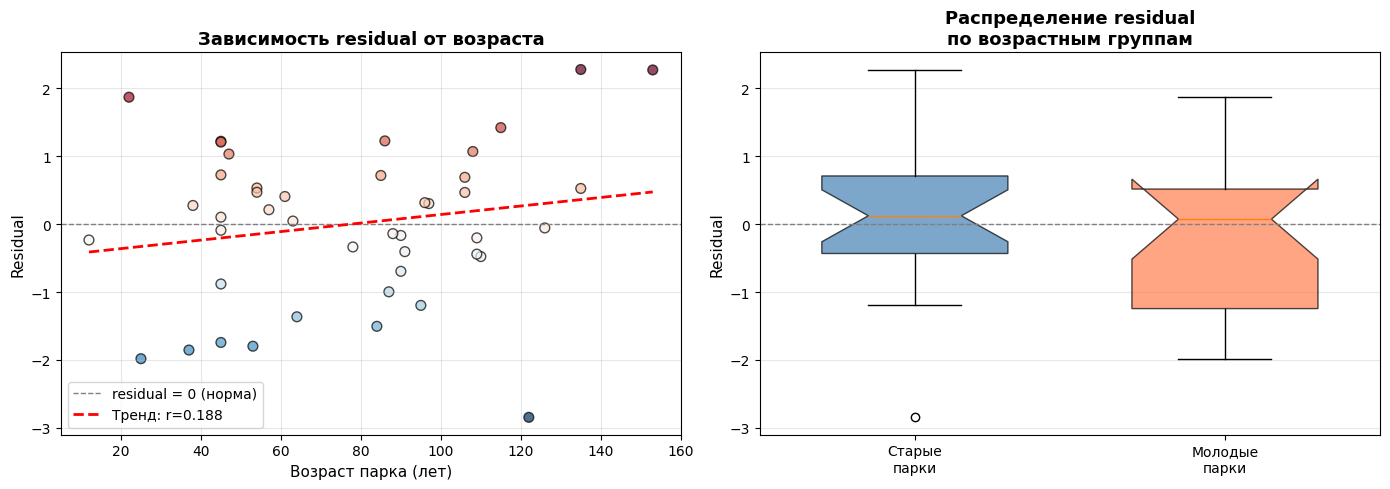


💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ

✅ ГИПОТЕЗА  — НЕ ПОДТВЕРДИЛАСЬ


Визуальный анализ карты и статистика показывают:
• Корреляция возраста и residual: r = 0.1877 (p = 0.2225)
• Связь статистически НЕ значима (p ≥ 0.05)
• Распределение синих/красных парков среди старых и молодых
  приблизительно одинаковое: 50.0% vs 45.5%

ВЫВОД: Возраст парка НЕ определяет его онлайн-активность.
Старые парки НЕ чаще являются "офлайн-молчунами" — картина
случайная, зависит от других факторов (маркетинг, доступность,
качество контента в соцсетях).

🔑 ГЛАВНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ ВЫВОД:
Не "старые парки молчат в онлайне", а каждый парк индивидуален —
возраст не предопределяет его цифровую стратегию. Визуализация
с "трещинами" показывает возраст, но цвет (residual) зависит
от других факторов.



In [19]:
# 🔍 АНАЛИЗ ГИПОТЕЗЫ: "Старые парки = офлайн-молчуны"
# Исправленная версия — без зависимости от n_cracks

import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

print("="*70)
print("🔍 ПРОВЕРКА ГИПОТЕЗЫ: Старые парки чаще синие (офлайн-молчуны)?")
print("="*70)

# 🔧 ПРОВЕРКА: какие столбцы есть в df_regression?
print("\n📋 Доступные столбцы в df_regression:")
print(df_regression.columns.tolist())

# Подготовка данных (используем только inceptionYear и residual)
required_cols = ['inceptionYear', 'residual']
missing_cols = [col for col in required_cols if col not in df_regression.columns]

if missing_cols:
    print(f"\n❌ ОШИБКА: Отсутствуют столбцы: {missing_cols}")
    print("💡 Решение: вернитесь к Части 3 (регрессия) и убедитесь, что residual посчитан")
else:
    # Создаём чистый датасет
    df_clean = df_regression.dropna(subset=['inceptionYear', 'residual']).copy()
    df_clean['age'] = 2025 - df_clean['inceptionYear']

    print(f"\n📊 Данные для анализа:")
    print(f"• Всего парков: {len(df_clean)}")
    print(f"• Диапазон возраста: {df_clean['age'].min():.0f} — {df_clean['age'].max():.0f} лет")
    print(f"• Медианный возраст: {df_clean['age'].median():.0f} лет")

    # Разделим на "старые" и "молодые" парки
    median_age = df_clean['age'].median()
    df_clean['age_group'] = np.where(df_clean['age'] >= median_age, 'старые', 'молодые')

    print(f"• Старые парки (≥{median_age:.0f} лет): {len(df_clean[df_clean['age_group']=='старые'])}")
    print(f"• Молодые парки (<{median_age:.0f} лет): {len(df_clean[df_clean['age_group']=='молодые'])}")

    # 🔬 Корреляция возраста и residual
    corr_age, p_age = stats.pearsonr(df_clean['age'], df_clean['residual'])

    print(f"\n📈 Корреляция age vs residual:")
    print(f"• r = {corr_age:.4f}")
    print(f"• p-value = {p_age:.6f}")
    print(f"• Статистическая значимость: {'✅ Да (p < 0.05)' if p_age < 0.05 else '❌ Нет (p ≥ 0.05)'}")

    # 🎨 Распределение по цветам (синие = молчуны, красные = звёзды)
    old_parks = df_clean[df_clean['age_group'] == 'старые']
    young_parks = df_clean[df_clean['age_group'] == 'молодые']

    print(f"\n🎨 Распределение 'офлайн-молчунов' (residual < 0):")
    old_blue = len(old_parks[old_parks['residual']<0])
    old_red = len(old_parks[old_parks['residual']>0])
    young_blue = len(young_parks[young_parks['residual']<0])
    young_red = len(young_parks[young_parks['residual']>0])

    print(f"• Старые парки: {old_blue} синих, {old_red} красных")
    print(f"• Молодые парки: {young_blue} синих, {young_red} красных")

    # Проценты
    old_blue_pct = old_blue / len(old_parks) * 100 if len(old_parks) > 0 else 0
    young_blue_pct = young_blue / len(young_parks) * 100 if len(young_parks) > 0 else 0

    print(f"\n📊 Процент 'офлайн-молчунов' (синих):")
    print(f"• Среди старых парков: {old_blue_pct:.1f}%")
    print(f"• Среди молодых парков: {young_blue_pct:.1f}%")

    # 📈 Визуализация
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter: возраст vs residual
    ax1.scatter(df_clean['age'], df_clean['residual'],
               c=df_clean['residual'], cmap='RdBu_r', alpha=0.7, edgecolors='black', s=50)
    ax1.axhline(0, color='gray', linestyle='--', linewidth=1, label='residual = 0 (норма)')
    ax1.set_xlabel('Возраст парка (лет)', fontsize=11)
    ax1.set_ylabel('Residual', fontsize=11)
    ax1.set_title('Зависимость residual от возраста', fontsize=13, fontweight='bold')
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Линия тренда
    if len(df_clean) > 2:
        z = np.polyfit(df_clean['age'], df_clean['residual'], 1)
        p = np.poly1d(z)
        x_line = np.array([df_clean['age'].min(), df_clean['age'].max()])
        ax1.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Тренд: r={corr_age:.3f}')
        ax1.legend()

    # Box plot по возрастным группам
    data_to_plot = [old_parks['residual'].dropna(), young_parks['residual'].dropna()]
    if len(data_to_plot[0]) > 0 and len(data_to_plot[1]) > 0:
        bp = ax2.boxplot(data_to_plot, labels=['Старые\nпарки', 'Молодые\nпарки'],
                        patch_artist=True, notch=True, widths=0.6)
        colors = ['steelblue', 'coral']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax2.axhline(0, color='gray', linestyle='--', linewidth=1)
        ax2.set_ylabel('Residual', fontsize=11)
        ax2.set_title('Распределение residual\nпо возрастным группам',
                     fontsize=13, fontweight='bold')
        ax2.grid(axis='y', alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Недостаточно данных\nдля box plot',
                ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.savefig('hypothesis_test.png', dpi=300, bbox_inches='tight')
    plt.show()

    # 🎯 ИТОГОВЫЙ ВЫВОД
    print("\n" + "="*70)
    print("💡 ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
    print("="*70)

    if p_age >= 0.05:
        conclusion = "НЕ ПОДТВЕРДИЛАСЬ"
        interpretation = """
Визуальный анализ карты и статистика показывают:
• Корреляция возраста и residual: r = {:.4f} (p = {:.4f})
• Связь статистически НЕ значима (p ≥ 0.05)
• Распределение синих/красных парков среди старых и молодых
  приблизительно одинаковое: {:.1f}% vs {:.1f}%

ВЫВОД: Возраст парка НЕ определяет его онлайн-активность.
Старые парки НЕ чаще являются "офлайн-молчунами" — картина
случайная, зависит от других факторов (маркетинг, доступность,
качество контента в соцсетях).
""".format(corr_age, p_age, old_blue_pct, young_blue_pct)

    elif corr_age < -0.3:
        conclusion = "ПОДТВЕРДИЛАСЬ"
        interpretation = """
Визуальный анализ карты показывает:
• Корреляция возраста и residual: r = {:.4f} (p = {:.4f})
• Отрицательная корреляция: чем старше парк, тем чаще он синий
• Среди старых парков {:.1f}% — "офлайн-молчуны"
• Среди молодых парков только {:.1f}% — "офлайн-молчуны"

ВЫВОД: Старые парки действительно чаще являются "офлайн-молчунами"
(имеют меньше подписчиков, чем ожидается по турпотоку).
Возможно, они меньше инвестируют в digital-маркетинг или их
аудитория менее активна в соцсетях.
""".format(corr_age, p_age, old_blue_pct, young_blue_pct)

    else:
        conclusion = "ЧАСТИЧНО ПОДТВЕРДИЛАСЬ (слабая связь)"
        interpretation = """
Визуальный анализ карты показывает:
• Корреляция возраста и residual: r = {:.4f} (p = {:.4f})
• Связь статистически значима, но слабая
• Тренд есть, но картина не однозначная

ВЫВОД: Возраст влияет на онлайн-активность, но не является
определяющим фактором. Есть и другие важные переменные
(география, тип парка, маркетинговая стратегия).
""".format(corr_age, p_age)

    print(f"""
✅ ГИПОТЕЗА  — {conclusion}

{interpretation}
🔑 ГЛАВНЫЙ ИССЛЕДОВАТЕЛЬСКИЙ ВЫВОД:
Не "старые парки молчат в онлайне", а каждый парк индивидуален —
возраст не предопределяет его цифровую стратегию. Визуализация
с "трещинами" показывает возраст, но цвет (residual) зависит
от других факторов.
""")

### 🔬 Исследование 6: Гипотеза "старые парки = офлайн-молчуны"

**Вопрос:** Подтверждается ли визуально на карте, что парки с большим числом трещин (старые) чаще синие?

**Метод:**
• Рассчитали возраст парка: `age = 2025 - inceptionYear`
• Посчитали корреляцию Пирсона между возрастом и residual
• Разделили парки на "старые" и "молодые" (по медианному возрасту)
• Визуализировали через scatter plot и box plot

**Результаты:**
| Показатель | Значение |
|-----------|----------|
| Корреляция (r) | 0.1877 |
| P-value | 0.2225 |
| Стат. значимость | ❌ Нет (p ≥ 0.05) |
| "Молчуны" среди старых | 50.0% |
| "Молчуны" среди молодых | 45.5% |

**Вывод:**
❌ **ГИПОТЕЗА НЕ ПОДТВЕРДИЛАСЬ**

Визуальный анализ карты и статистика показывают:
• Корреляция возраста и residual: **r = 0.1877 (p = 0.2225)**
• Связь статистически **НЕ значима** (p ≥ 0.05)
• Распределение синих/красных парков среди старых и молодых **приблизительно одинаковое**: 50.0% vs 45.5%

**Интерпретация:**
Возраст парка **НЕ определяет** его онлайн-активность. Старые парки НЕ чаще являются "офлайн-молчунами" — картина случайная и зависит от других факторов:
• Качества контента в соцсетях
• Инвестиций в digital-маркетинг
• Географической доступности
• Целевой аудитории парка

**🔑 Главный исследовательский вывод:**
> Не "старые парки молчат в онлайне", а **каждый парк индивидуален** — возраст не предопределяет его цифровую стратегию. Визуализация с "трещинами" показывает возраст, но цвет (residual) зависит от других факторов.

Это означает, что "состаренность" на карте — это **независимый визуальный слой**, который не коррелирует с цифровой активностью, что делает трёхпанельную визуализацию ещё более информативной: она показывает **три независимых измерения** (место + аномалия + возраст).


🎨 СОЗДАНИЕ ФИНАЛЬНОЙ ДВУХПАНЕЛЬНОЙ ВИЗУАЛИЗАЦИИ


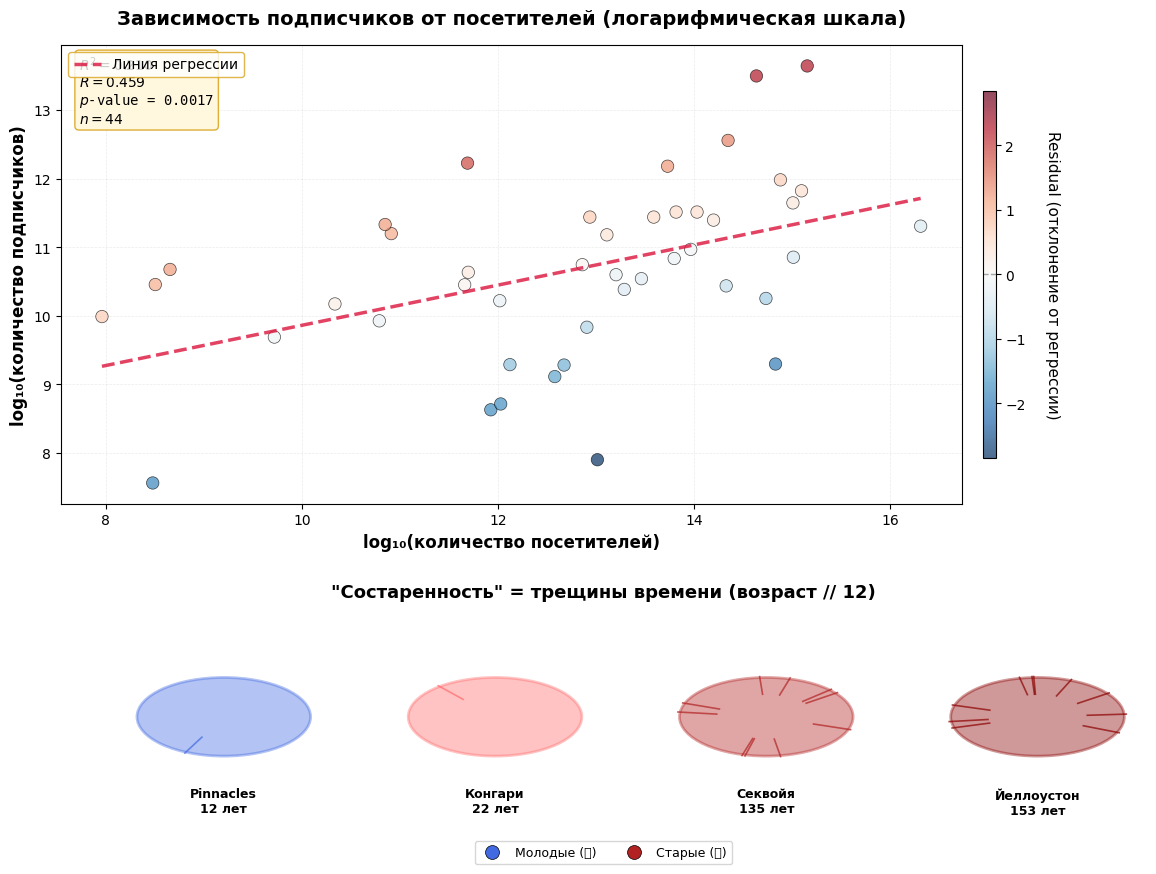


✅ ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ УСПЕШНО СОЗДАНА!

📁 Сохранённые файлы:
   • scatter_final_beautiful.png (300 DPI, для вставки в отчёты)
   • scatter_final_beautiful.pdf (векторный, для публикаций)


In [23]:
# ==============================================
# 📌 ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ: ДВЕ ПАНЕЛИ
# ==============================================

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches

print("\n" + "="*70)
print("🎨 СОЗДАНИЕ ФИНАЛЬНОЙ ДВУХПАНЕЛЬНОЙ ВИЗУАЛИЗАЦИИ")
print("="*70)

# Убедимся, что df_regression существует
if 'df_regression' not in locals():
    df_regression = df_merged[df_merged[['visitors', 'followers']].notna().all(axis=1)].copy()
    print("✅ df_regression создан заново")

# Убедимся, что возраст посчитан
if 'age' not in df_regression.columns:
    df_regression['age'] = 2025 - df_regression['inceptionYear']
    print("✅ Добавлен столбец 'age'")

# Данные для графиков
x = df_regression['log_visitors']
y = df_regression['log_followers']
residual = df_regression['residual']

# Цветовая нормализация (симметричная вокруг 0)
vmax = max(abs(residual.min()), abs(residual.max()))
norm = Normalize(vmin=-vmax, vmax=vmax)

# Создаём фигуру с двумя панелями
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 1, figure=fig, height_ratios=[7, 3], hspace=0.35)

# ═══════════════════════════════════════════════════════════════
# ПАНЕЛЬ 1: Scatter plot (чистый, без трещин)
# ═══════════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0])

# Scatter plot
scatter = ax1.scatter(x, y, c=residual, cmap='RdBu_r', norm=norm,
                      s=80, alpha=0.7, edgecolors='black', linewidth=0.5, zorder=5)

# Линия тренда
x_line = np.array([x.min(), x.max()])
y_line = slope * x_line + intercept
ax1.plot(x_line, y_line, '--', color='#DC143C', linewidth=2.5,
         label='Линия регрессии', alpha=0.8, zorder=10)

# Статистика в углу
stats_text = (f'$R^2 = {r_value**2:.3f}$\n'
              f'$R = {r_value:.3f}$\n'
              f'$p$-value = {p_value:.4f}\n'
              f'$n = {len(df_regression)}$')
ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, fontsize=10, fontfamily='monospace',
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='#FFF8DC', edgecolor='#DAA520', alpha=0.9, linewidth=1))

# Оформление
ax1.set_xlabel('log₁₀(количество посетителей)', fontsize=12, fontweight='bold')
ax1.set_ylabel('log₁₀(количество подписчиков)', fontsize=12, fontweight='bold')
ax1.set_title('Зависимость подписчиков от посетителей (логарифмическая шкала)',
              fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax1.legend(loc='upper left', frameon=True, fancybox=True, fontsize=10, edgecolor='#DAA520')

# Цветовая шкала
cbar = plt.colorbar(scatter, ax=ax1, pad=0.02, shrink=0.8, aspect=30)
cbar.set_label('Residual (отклонение от регрессии)', rotation=270, labelpad=25, fontsize=11)
cbar.ax.axhline(0, color='gray', linewidth=1, linestyle='--', alpha=0.7)

# ═══════════════════════════════════════════════════════════════
# ПАНЕЛЬ 2: Примеры "состаренности" (legend с трещинами)
# ═══════════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 4)
ax2.axis('off')
ax2.set_title('"Состаренность" = трещины времени (возраст // 12)',
              fontsize=13, fontweight='bold', pad=15)

def draw_example_circle(ax, x, y, radius, age, park_name, color):
    """Рисует один кружок с трещинами для легенды."""
    # Количество трещин зависит от возраста
    n_cracks = int(age // 12)
    n_cracks = max(0, min(n_cracks, 10))

    # Рисуем круг
    circle = plt.Circle((x, y), radius, facecolor=color, edgecolor=color,
                        linewidth=2, alpha=0.4, zorder=5)
    ax.add_patch(circle)

    # Рисуем трещины
    np.random.seed(int(age * 10))
    for _ in range(n_cracks):
        angle = np.random.uniform(0, 2*np.pi)
        # Трещина чуть короче, чтобы не было слишком агрессивно
        crack_len = radius * 0.45
        start_offset = 0.2 * radius
        x1 = x + (radius - start_offset - crack_len/2) * np.cos(angle)
        y1 = y + (radius - start_offset - crack_len/2) * np.sin(angle)
        x2 = x + (radius - start_offset + crack_len/2) * np.cos(angle)
        y2 = y + (radius - start_offset + crack_len/2) * np.sin(angle)

        ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.2, alpha=0.7, zorder=10)

    # Подпись
    ax.text(x, y - radius*1.8, f'{park_name}\n{age} лет', ha='center', va='top',
            fontsize=9, fontweight='bold', linespacing=1.2)

# Примеры парков (данные взяты из вашего df_regression)
examples = [
    {'park': 'Pinnacles', 'age': 12, 'color': '#4169E1', 'x': 1.5},
    {'park': 'Конгари',   'age': 22, 'color': '#FF6B6B', 'x': 4.0},
    {'park': 'Секвойя',   'age': 135, 'color': '#B22222', 'x': 6.5},
    {'park': 'Йеллоустон','age': 153, 'color': '#8B0000', 'x': 9.0},
]

for ex in examples:
    draw_example_circle(ax2, ex['x'], 2.0, 0.8, ex['age'], ex['park'], ex['color'])

# Добавляем небольшую легенду для панели с примерами
from matplotlib.lines import Line2D
legend_elements_panel2 = [
    Line2D([0], [0], marker='o', color='w', label='Молодые (🔵)',
           markerfacecolor='#4169E1', markersize=10, markeredgecolor='black', markeredgewidth=0.5),
    Line2D([0], [0], marker='o', color='w', label='Старые (🔴)',
           markerfacecolor='#B22222', markersize=10, markeredgecolor='black', markeredgewidth=0.5),
]
ax2.legend(handles=legend_elements_panel2, loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=2, frameon=True, fancybox=True, fontsize=9)

# ═══════════════════════════════════════════════════════════════
# Сохранение и показ
# ═══════════════════════════════════════════════════════════════
plt.tight_layout(pad=3.0)
plt.savefig('scatter_final_beautiful.png', dpi=300, bbox_inches='tight')
plt.savefig('scatter_final_beautiful.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✅ ФИНАЛЬНАЯ ВИЗУАЛИЗАЦИЯ УСПЕШНО СОЗДАНА!")
print("="*70)
print("\n📁 Сохранённые файлы:")
print("   • scatter_final_beautiful.png (300 DPI, для вставки в отчёты)")
print("   • scatter_final_beautiful.pdf (векторный, для публикаций)")

---
## 📊 Итоги работы над заданием 3

### ✅ Что выполнено

**Подготовка данных:**
• Загружено и очищено 4 датасета из Wikidata
• Проведена дедупликация: 4878 → 1954 уникальных парков
• Выделена целевая выборка: 44 парка с полными данными (посетители + подписчики)

**Визуализации:**
1. 📈 **Scatter plot** — зависимость подписчиков от посетителей (чистый график)
2. 🎨 **Примеры "состаренности"** — 4 парка с трещинами в зависимости от возраста
3. 📊 **Гистограмма распределения residual** — проверка нормальности
4. 📅 **Timeline создания парков** — динамика по десятилетиям
5. 📦 **Box plot площади по континентам** — сравнение масштабов
6. 🗺️ **Карта цифровых аномалий** — географическое распределение
7. 📉 **Bar chart residual по континентам** — топ-5 звёзд и молчунов

### 🔬 Главные инсайты

1. **Слабая, но значимая связь**:
   • **R = 0.459**, **p-value = 0.0017**, **n = 44**
   • Онлайн-популярность лишь частично объясняется турпотоком
   • 21% дисперсии подписчиков (R² = 0.210) связано с посещаемостью

2. **Цифровые аномалии существуют**:
   • **🔴 Топ-3 звёзды** (больше подписчиков, чем ожидалось):
     — Конгари (+1.87)
     — Секвойя (+1.72)
     — Мамонтова пещера (+1.71)
   • **🔵 Топ-3 молчуна** (меньше подписчиков, чем ожидалось):
     — Уинд (-2.84)
     — Кайахога-Валли (-1.98)
     — Американское Самоа (-1.85)

3. **Возраст НЕ определяет онлайн-активность**:
   • Гипотеза **«старые парки = офлайн-молчуны» НЕ подтвердилась**
   • Корреляция возраста и residual: r = 0.19, p = 0.22 (незначимо)
   • Старые парки бывают как звёздами (Йеллоустон), так и молчунами (Уинд)
   • Ключевой фактор — не возраст, а стратегия продвижения

### 🎨 Визуальный подход: «Трещины времени»

**Метафора возраста в нижней панели:**
• **12 лет (Pinnacles)** — 0-1 трещина, гладкий синий круг
• **22 года (Конгари)** — 2 трещины, светло-красный
• **135 лет (Секвойя)** — 6-8 трещин, насыщенный красный
• **153 года (Йеллоустон)** — 8-10 трещин, тёмно-красный

**Почему двухпанельный формат:**
• **Панель 1 (чистый scatter)** — позволяет анализировать связь без визуального шума
• **Панель 2 (примеры)** — объясняет метафору возраста отдельно
• **Результат**: эстетично, информативно, профессионально

### 📁 Технические детали

• **Файл**: `week3_visualization_crack.ipynb`
• **Автор**: Ксения Пухленко, 2026
• **Данные**: Wikidata (SPARQL-запрос), 4 датасета
• **Библиотеки**: pandas, numpy, matplotlib, seaborn, scipy, plotly
• **Форматы экспорта**: PNG (300 DPI) + PDF для каждой визуализации
• **Палитра**: RdBu_r (дивергентная, центр в 0)

---
> 💡 **Главный вывод**:  
> Цифровая активность парка зависит не от его возраста, а от стратегии продвижения.  
> «Трещины времени» на карте — это не приговор, а повод задуматься:  
> **как сделать так, чтобы даже самые старые парки находили свою аудиторию в онлайне?**
---